## Setup / Imports

### 1. Imports and environment sanity check

In this cell, we import the core `multimodal_mazes` library and basic utilities, and print out the current working directory (CWD) and the path from which the package is loaded.

This serves two purposes:
- It confirms that the notebook is being run from the `scripts/` folder, which is required because the library uses relative paths for plotting styles.
- It confirms that Python is using the editable installation of `multimodal_mazes` from this repository, rather than a cached or incorrect version.

This step helps catch environment and path issues early, before running any experiments.


In [34]:
import os
import numpy as np
import multimodal_mazes

print("CWD:", os.getcwd())
print("multimodal_mazes:", multimodal_mazes.__file__)


CWD: /Users/lakshaasrishankar/Documents/Important Documents /Dr Marcus Ghosh Project/Multimodal_mazes/scripts
multimodal_mazes: /Users/lakshaasrishankar/Documents/Important Documents /Dr Marcus Ghosh Project/Multimodal_mazes/multimodal_mazes/__init__.py


### 2. Generating a batch of mazes

Here we create a `GeneralMaze` task and generate a batch of independent mazes.

- `size=33` defines a 33×33 grid.
- `n_channels=2` specifies that each maze contains two sensory cue channels.
- `maze.generate(number=10)` samples 10 different mazes from the task distribution.

The resulting `maze` object stores:
- the maze layouts themselves (`maze.mazes`)
- the start locations (`maze.start_locations`)
- the goal locations (`maze.goal_locations`)
- the length of the shortest possible path for each maze (`maze.fastest_solutions`)

This defines the environment distribution that agents will be evaluated on.


In [35]:
maze = multimodal_mazes.GeneralMaze(size=33, n_channels=2)
maze.generate(number=10)

print("mazes:", len(maze.mazes))
print("start_locations:", len(maze.start_locations))
print("goal_locations:", len(maze.goal_locations))
print("fastest_solutions:", len(maze.fastest_solutions))
print("maze[0] shape:", maze.mazes[0].shape)


mazes: 10
start_locations: 10
goal_locations: 10
fastest_solutions: 10
maze[0] shape: (33, 33, 3)


### 3. Inspecting maze structure and sensory channels

Each maze is stored as a NumPy array of shape `(size, size, n_channels + 1)`.

In this cell, we separate:
- the **structural channel** (`mz[:, :, -1]`), which encodes walls (0.0) and free paths (1.0)
- the **sensory cue channels** (`mz[:, :, :-1]`), which provide gradient-like information guiding the agent toward the goal

Inspecting these components helps verify:
- the expected data shapes
- the range of values in the sensory cues
- our understanding of what information is available to the agent at each location


In [36]:
n = 0
mz = maze.mazes[n]

structure = mz[:, :, -1]
cues = mz[:, :, :-1]

print("structure unique values:", np.unique(structure))
print("cues shape:", cues.shape)  # (33, 33, 2)
print("cues min/max:", cues.min(), cues.max())


structure unique values: [0. 1.]
cues shape: (33, 33, 2)
cues min/max: 0.0 0.5


### 4. Creating a rule-based agent

Here we create a simple, non-learning agent using the `AgentRuleBased` class.

This agent:
- senses both sensory channels
- combines them using a linear fusion policy
- moves in the direction of the strongest combined signal

This agent serves as a baseline:
- it does not learn
- it has no internal memory or recurrence
- its behaviour is fully determined by the current sensory input

Using this simple agent allows us to validate the task setup before introducing neural or recurrent agents.


In [37]:
agnt = multimodal_mazes.AgentRuleBased(
    location=None,
    channels=[1, 1],
    policy="Linear fusion"
)

print("Agent:", type(agnt))


Agent: <class 'multimodal_mazes.agents.agent_rulebased.AgentRuleBased'>


### 5. Single maze trial and path visualisation

In this cell, we test the agent on a single maze instance.

The `maze_trial` function runs one episode in which the agent:
- starts at the maze's start location
- repeatedly senses its local environment
- selects an action based on its policy
- moves within the maze for up to `n_steps`

The function returns:
- the time taken (or failure indicator)
- the full trajectory of the agent's path

We then visualise the path overlaid on the maze, providing a qualitative check that the agent's behaviour is sensible and goal-directed.


time: 99
path length: 101


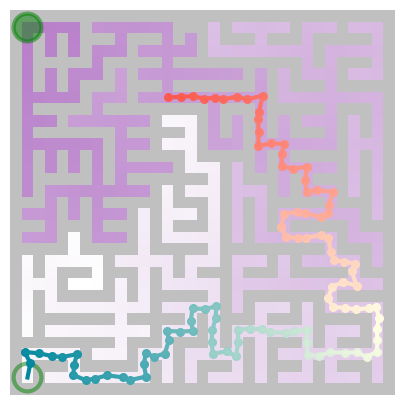

In [38]:
n = 0

time, path = multimodal_mazes.maze_trial(
    mz=maze.mazes[n],
    mz_start_loc=maze.start_locations[n],
    mz_goal_loc=maze.goal_locations[n],
    channels=[1,1],
    sensor_noise_scale=0.0,
    drop_connect_p=0.0,
    n_steps=100,
    agnt=agnt
)

print("time:", time)
print("path length:", len(path) if path is not None else None)

multimodal_mazes.plot_path(
    path,
    mz=maze.mazes[n],
    mz_goal_loc=maze.goal_locations[n],
    n_steps=100,
    style="gradients"
)


### 6. Batch evaluation and fitness computation

Here we evaluate the agent across the full batch of generated mazes.

The `eval_fitness` function:
- runs the agent on each maze in the batch
- compares the path taken to the maze's shortest possible path
- aggregates performance into a single fitness score between 0 and 1

A fitness value of:
- 1.0 indicates the agent always takes the optimal (shortest) path
- lower values indicate inefficiency or failure on some mazes

This quantitative score enables systematic comparison between different agents, architectures, and experimental conditions later in the project.


In [39]:
fitness = multimodal_mazes.eval_fitness(
    genome=None,
    config=None,
    channels=[1,1],
    sensor_noise_scale=0.0,
    drop_connect_p=0.0,
    maze=maze,
    n_steps=100,
    agnt=agnt
)

print("fitness:", fitness)


fitness: 0.8856216628527841


### 1. Experiment paths and setup

In this cell, we define the file system paths used in this experiment.

The trained agents are stored externally in the `pRNN_data` directory, organised into run folders such as `test1352`, each containing multiple pickled agents (e.g. `128.pickle`).

### Load feedforward (1.pickle) and fully recurrent (128.pickle) agents

We now load two agents from the same run:
- `1.pickle`: feedforward network  
- `128.pickle`: fully recurrent network  

These will be evaluated under the same perturbation protocol for a direct architectural comparison.

We explicitly define:
- the root results directory
- the specific run folder to analyse
- the agent ID to load

Using `pathlib.Path` makes the code robust to spaces in file paths and avoids fragile relative path assumptions.


In [40]:
from pathlib import Path
import pickle
import multimodal_mazes


RESULTS_DIR = Path("/Users/lakshaasrishankar/Documents/Important Documents /Dr Marcus Ghosh Project/datasets/pRNN_data")
RUN_NAME = "test1352"
RUN_DIR = RESULTS_DIR / RUN_NAME

AGENT_CONFIGS = [
    {"agent_id": 1,   "arch": "FF"},
    {"agent_id": 128, "arch": "RNN_full"},
]

agents = {}

for cfg in AGENT_CONFIGS:
    aid = cfg["agent_id"]
    arch = cfg["arch"]
    p = RUN_DIR / f"{aid}.pickle"
    print(f"Loading agent {aid} ({arch}) from:", p)
    print("  Exists:", p.exists())
    with open(p, "rb") as f:
        a = pickle.load(f)
    agents[aid] = {"arch": arch, "obj": a}



Loading agent 1 (FF) from: /Users/lakshaasrishankar/Documents/Important Documents /Dr Marcus Ghosh Project/datasets/pRNN_data/test1352/1.pickle
  Exists: True
Loading agent 128 (RNN_full) from: /Users/lakshaasrishankar/Documents/Important Documents /Dr Marcus Ghosh Project/datasets/pRNN_data/test1352/128.pickle
  Exists: True


In [41]:
for aid, info in agents.items():
    a = info["obj"]
    print(aid, info["arch"], "wm_flags:", getattr(a, "wm_flags", None))


1 FF wm_flags: [0 0 0 0 0 0 0]
128 RNN_full wm_flags: [1 1 1 1 1 1 1]


### 2. Generating mazes for baseline evaluation

Here we generate a new batch of mazes using the parameters specified in Marcus’s example:

- maze size: 9 × 9
- number of sensory channels: 2
- number of mazes: 1000

These mazes are generated in memory and are *not* loaded from disk.  
They form the evaluation environment on which the saved agent’s performance will be measured.


In [42]:
maze = multimodal_mazes.GeneralMaze(size=9, n_channels=2)
maze.generate(number=1000)

print("Mazes:", len(maze.mazes))


Mazes: 1000


### 3. Loading a trained agent

In this cell, we load a previously trained agent from disk using Python’s `pickle` module.

Each `.pickle` file contains a fully specified agent object, including its learned policy and internal parameters.  
Loading the agent allows us to evaluate its behaviour without retraining.

This step verifies that:
- the agent files are compatible with the current codebase
- the agent can be instantiated correctly in memory


In [43]:
# Load one trained agent for the single-trial demo below.
# The cohort-level loop in Part 3 will load many agents; this is just a demo.
agent_path = RUN_DIR / "128.pickle"
with open(agent_path, "rb") as f:
    agnt = pickle.load(f)

print("Loaded agent type:", type(agnt))
print("From:", agent_path)


Loaded agent type: <class 'multimodal_mazes.agents.agent_dqn.AgentDQN'>
From: /Users/lakshaasrishankar/Documents/Important Documents /Dr Marcus Ghosh Project/datasets/pRNN_data/test1352/128.pickle


### 4. Single-maze trial and trajectory visualisation

Here we test the loaded agent on a single maze instance.

The `maze_trial` function runs one episode in which the agent:
- starts from the maze’s start location
- senses local cues with added sensor noise
- selects actions according to its learned policy
- moves for up to 20 time steps

We then visualise the resulting trajectory over the maze.  
This provides a qualitative check that the agent’s behaviour is sensible under the specified noise and step constraints.



=== Agent 1 (FF) on maze 0 ===
time: 15 path length: 17

=== Agent 128 (RNN_full) on maze 0 ===
time: 13 path length: 15


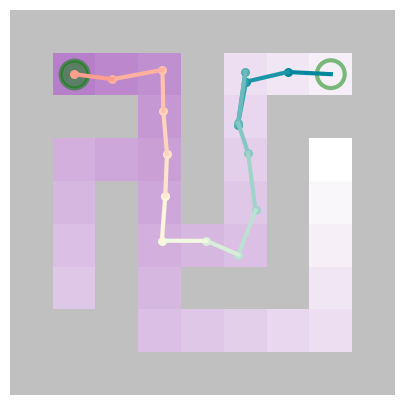

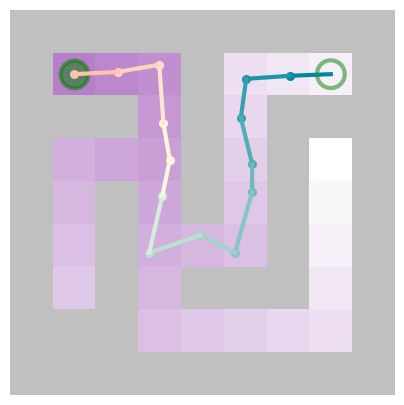

In [44]:
n = 0 
results = {}

for aid, info in agents.items():
    agnt = info["obj"]
    arch = info["arch"]

    print(f"\n=== Agent {aid} ({arch}) on maze {n} ===")
    time, path = multimodal_mazes.maze_trial(
        mz=maze.mazes[n],
        mz_start_loc=maze.start_locations[n],
        mz_goal_loc=maze.goal_locations[n],
        channels=[1, 1],
        sensor_noise_scale=0.05,
        drop_connect_p=0.0,
        n_steps=20,
        agnt=agnt,
    )

    results[aid] = {"time": time, "path": path}

    print("time:", time, "path length:", len(path) if path is not None else None)

    multimodal_mazes.plot_path(
        path,
        mz=maze.mazes[n],
        mz_goal_loc=maze.goal_locations[n],
        n_steps=20,
        style="gradients",
    )



### 5. Batch fitness evaluation

In this final step, we evaluate the agent across all 1000 generated mazes.

The `eval_fitness` function:
- runs the agent on each maze
- compares the path taken to the maze’s shortest possible path
- aggregates performance into a single fitness score between 0 and 1

This fitness value provides a quantitative summary of the agent’s navigation efficiency and is used to compare performance across agents, runs, and experimental conditions.


In [45]:
fitness_scores = {}

for aid, info in agents.items():
    agnt = info["obj"]

    fitness = multimodal_mazes.eval_fitness(
        genome=None,
        config=None,
        channels=[1,1],
        sensor_noise_scale=0.05,
        drop_connect_p=0.0,
        maze=maze,
        n_steps=20,
        agnt=agnt
    )

    fitness_scores[aid] = fitness
    print(f"Agent {aid} ({info['arch']}): fitness={fitness}")


/Users/lakshaasrishankar/Documents/Important Documents /Dr Marcus Ghosh Project/Multimodal_mazes/multimodal_mazes/mazes/maze_trial.py:164: RuntimeWarning: invalid value encountered in scalar divide
  (time - maze.fastest_solutions[mz_n])


Agent 1 (FF): fitness=0.7530513371879393
Agent 128 (RNN_full): fitness=0.7672287457654956


## Part 2 - Perturbation experiment (seizure-like hidden-state noise)

Goal: test robustness of a trained agent by injecting a temporary perturbation into its *internal hidden state* during maze navigation.

We will:
1) identify where the AgentDQN stores its hidden / recurrent state,
2) define a perturbation schedule (onset, duration, intensity),
3) run repeated trials across many mazes,
4) summarise performance degradation as fitness / success under perturbation.


In [46]:
import numpy as np
import pandas as pd
import multimodal_mazes

print("Mazes:", len(maze.mazes))
print("Agent:", type(agnt))


Mazes: 1000
Agent: <class 'multimodal_mazes.agents.agent_dqn.AgentDQN'>


### 2.1 Discover how AgentDQN stores hidden state

We need to locate the agent's internal "memory" (hidden state) so we can inject perturbations.

This cell inspects attributes and prints anything that looks like:
- hidden state vectors (e.g., `h`, `hidden`, `state`, `wm`, `memory`)
- policy/network objects that might contain recurrent state


In [47]:
def list_suspicious_attrs(obj, keywords=("hid", "state", "mem", "wm", "rnn", "rec", "cell")):
    hits = []
    for name in dir(obj):
        lname = name.lower()
        if any(k in lname for k in keywords):
            try:
                val = getattr(obj, name)
                hits.append((name, type(val)))
            except Exception:
                pass
    return hits

hits = list_suspicious_attrs(agnt)
print("Suspicious AgentDQN attrs:")
for n, t in hits:
    print(f"  - {n}: {t}")

# Also inspect nested policy/network if present
for candidate in ["policy", "net", "network", "model", "q_net", "qnet"]:
    if hasattr(agnt, candidate):
        obj = getattr(agnt, candidate)
        print(f"\nFound agnt.{candidate} -> {type(obj)}")
        subhits = list_suspicious_attrs(obj)
        for n, t in subhits[:30]:
            print(f"  - {candidate}.{n}: {t}")


Suspicious AgentDQN attrs:
  - __getstate__: <class 'method'>
  - __setstate__: <class 'method'>
  - _load_from_state_dict: <class 'method'>
  - _load_state_dict_post_hooks: <class 'collections.OrderedDict'>
  - _load_state_dict_pre_hooks: <class 'collections.OrderedDict'>
  - _named_members: <class 'method'>
  - _register_load_state_dict_pre_hook: <class 'method'>
  - _register_state_dict_hook: <class 'method'>
  - _save_to_state_dict: <class 'method'>
  - _state_dict_hooks: <class 'collections.OrderedDict'>
  - _state_dict_pre_hooks: <class 'collections.OrderedDict'>
  - get_extra_state: <class 'method'>
  - hidden: <class 'torch.Tensor'>
  - hidden_to_hidden: <class 'torch.nn.modules.linear.Linear'>
  - hidden_to_input: <class 'torch.nn.modules.linear.Linear'>
  - hidden_to_output: <class 'torch.nn.modules.linear.Linear'>
  - input_to_hidden: <class 'torch.nn.modules.linear.Linear'>
  - load_state_dict: <class 'method'>
  - memory: <class 'numpy.ndarray'>
  - n_hidden_units: <class 

## 2.2 Step-wise perturbation hook (input / hidden / output)

`AgentDQN` exposes three points in its sensation–action loop where a
seizure-like signal can be injected, matching Dr Ghosh's suggestion to
*compare noise at input, hidden, and output*:

- **input**  — `agnt.channel_inputs`, the freshly sensed observation, perturbed
  after `sense()` but before the forward pass reads it. Defined for **every**
  architecture, including feedforward.
- **hidden** — `agnt.hidden`, the *t-1* recurrent state fed into the forward
  pass. Only has an effect on architectures whose `wm_flags` route the hidden
  state forward (`hh`/`oh`); for a pure feedforward agent the hidden state is
  overwritten unused, so this locus is a no-op there *by design*.
- **output** — `agnt.outputs`, the action values, perturbed after the forward
  pass but before `act()` selects a move. Defined for **every** architecture.

We wrap (`monkeypatch`) `agnt.policy` so that on each call we increment a
timestep counter and inject Gaussian noise at the chosen locus during the
window `[onset, onset+duration)`. Over a long window this is per-step white
noise (Dr Ghosh: *"long duration -> more like noise"*).

Note: `agnt.memory` and `agnt.wm_flags` are **not** runtime state — `memory` is
a scalar written by the test harness and `wm_flags` is the fixed architecture
spec — so neither is a valid perturbation target. Reproducibility requires
seeding **both** numpy (input locus) and torch (hidden/output loci), because
the agent's tensors draw from the torch RNG.


In [ ]:
import numpy as np

def apply_perturbation(x, mode, sigma, tau, duration, ctx, rng,
                       freq=0.25, clamp_scale=5.0):
    """Return a perturbed copy of 1-D array x at within-window step tau (0-based).

    Seizure-like perturbation modes. `ctx` is a per-trial dict ({} at trial
    start) holding vectors that must stay FIXED across the window (drift
    direction, oscillation pattern, clamp signs). `rng` is a numpy Generator.

    ADDITIVE modes share a per-step RMS budget set by sigma (directly
    comparable on the sigma axis); they differ only in temporal/spatial
    structure:
      gaussian    : zero-mean white noise, resampled each step.
      drift       : a fixed random direction, held constant -> coherent push
                    (tonic depolarisation). Same per-step RMS as gaussian, but
                    accumulates rather than cancelling.
      oscillatory : a fixed spatial pattern * sin(2*pi*freq*tau) -> rhythmic /
                    epileptiform. Amplitude sigma*sqrt(2) so the TIME-AVERAGED
                    per-element RMS equals sigma. (Budget by cumulative impulse,
                    NOT net displacement: a full cycle nets ~0 and would
                    mis-scale the mode by ~10x.)
      burst       : the window's whole energy in one transient at tau==0
                    (amplitude sigma*sqrt(duration)); zero otherwise.

    NON-ADDITIVE failure mode (separate axis -- a magnitude, not energy):
      clamp       : overwrite the state with a fixed saturated pattern
                    (+/- sigma*clamp_scale) for the whole window
                    (depolarisation block / information destruction).
    """
    d = x.size
    if mode == "gaussian":
        return x + sigma * rng.standard_normal(d).reshape(x.shape)
    if mode == "burst":
        if tau == 0:
            return x + sigma * np.sqrt(duration) * rng.standard_normal(d).reshape(x.shape)
        return x
    if mode == "drift":
        if "dir" not in ctx:
            ctx["dir"] = rng.standard_normal(d).reshape(x.shape)
        return x + sigma * ctx["dir"]
    if mode == "oscillatory":
        if "pat" not in ctx:
            ctx["pat"] = rng.standard_normal(d).reshape(x.shape)
        return x + (sigma * np.sqrt(2.0)) * np.sin(2 * np.pi * freq * tau) * ctx["pat"]
    if mode == "clamp":
        if "sat" not in ctx:
            ctx["sat"] = rng.choice([-1.0, 1.0], size=d).reshape(x.shape)
        return (sigma * clamp_scale) * ctx["sat"]      # override (not additive)
    raise ValueError(f"unknown perturbation mode {mode!r}")


In [ ]:
import numpy as np
import torch
import types


def attach_perturbation_hook(
    agnt,
    onset: int,
    duration: int,
    sigma: float,
    locus: str = "hidden",      # "input", "hidden", or "output"
    mode: str = "gaussian",     # see apply_perturbation
    seed=None,
    freq: float = 0.25,
    clamp_scale: float = 5.0,
):
    """
    Wrap agnt.policy so that, during timesteps t in [onset, onset+duration),
    a seizure-like perturbation (see `apply_perturbation` for the modes) is
    applied at the chosen locus:
      - "input"  : agnt.channel_inputs  (after sense(), before the forward pass)
      - "hidden" : agnt.hidden           (the t-1 recurrent state fed forward)
      - "output" : agnt.outputs          (after the forward pass, before act())

    All perturbation noise is drawn from a single numpy Generator (seeded), so
    every mode/locus is reproducible from `seed`. Returns a detach() callable.
    """
    if locus not in ("input", "hidden", "output"):
        raise ValueError(f"locus must be input/hidden/output, got {locus!r}")

    rng = np.random.default_rng(seed)
    ctx = {}                      # per-trial store for fixed within-window vectors

    original_policy = agnt.policy
    agnt._perturb_t = 0

    def _perturb(arr_np, tau):
        return apply_perturbation(
            arr_np.ravel(), mode, sigma, tau, duration, ctx, rng,
            freq=freq, clamp_scale=clamp_scale,
        ).reshape(arr_np.shape)

    def wrapped_policy(self, *args, **kwargs):
        t = self._perturb_t
        self._perturb_t += 1
        tau = t - onset
        active = (onset <= t < onset + duration) and (sigma > 0)

        if active and locus == "input":
            self.channel_inputs = _perturb(np.asarray(self.channel_inputs, dtype=float), tau)

        if active and locus == "hidden":
            xp = _perturb(self.hidden.detach().numpy().astype(float), tau)
            self.hidden = torch.from_numpy(xp).float()

        out = original_policy(*args, **kwargs)

        if active and locus == "output":
            xp = _perturb(self.outputs.detach().numpy().astype(float), tau)
            self.outputs = torch.from_numpy(xp).float()

        return out

    agnt.policy = types.MethodType(wrapped_policy, agnt)

    def detach():
        agnt.policy = original_policy
        if hasattr(agnt, "_perturb_t"):
            del agnt._perturb_t

    return detach


In [49]:
# Inspect the loaded agent's hidden state vector
print("agnt.hidden:", agnt.hidden)
print("agnt.hidden.shape:", tuple(agnt.hidden.shape))


agnt.hidden: tensor([0.0000, 0.6477, 0.0000, 2.9002, 0.0000, 0.0000, 0.0000, 0.0000])
agnt.hidden.shape: (8,)


### 2.3 Sanity check: single perturbed episode

Before running large-scale experiments, we validate that the hidden-state
perturbation mechanism works as intended by applying it to a single maze trial.

We compare the perturbed trajectory to the unperturbed baseline to ensure
that the perturbation meaningfully alters behaviour without breaking execution.



=== Agent 1 (FF) - hidden perturbation ===
PERTURBED time: 15
PERTURBED path length: 17

=== Agent 128 (RNN_full) - hidden perturbation ===
PERTURBED time: 19
PERTURBED path length: 21


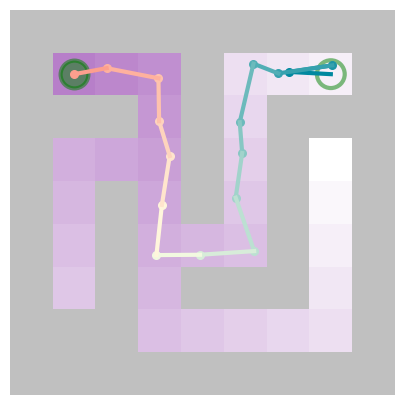

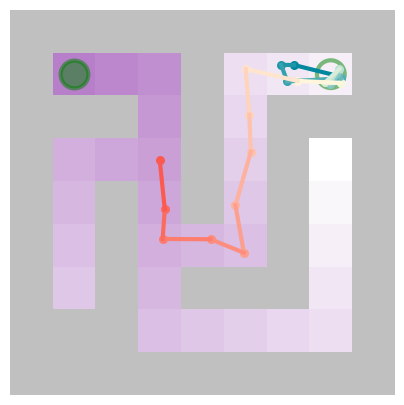

In [50]:
for aid, info in agents.items():
    ag = info["obj"]
    arch = info["arch"]

    print(f"\n=== Agent {aid} ({arch}) - hidden perturbation ===")

    detach = attach_perturbation_hook(
        ag,
        onset=5,
        duration=10,
        sigma=0.5,
        locus="hidden",
        seed=0,
    )

    time_p, path_p = multimodal_mazes.maze_trial(
        mz=maze.mazes[0],
        mz_start_loc=maze.start_locations[0],
        mz_goal_loc=maze.goal_locations[0],
        channels=[1, 1],
        sensor_noise_scale=0.05,
        drop_connect_p=0.0,
        n_steps=20,
        agnt=ag,
    )

    detach()

    print("PERTURBED time:", time_p)
    print("PERTURBED path length:", len(path_p) if path_p is not None else None)

    multimodal_mazes.plot_path(
        path_p,
        mz=maze.mazes[0],
        mz_goal_loc=maze.goal_locations[0],
        n_steps=20,
        style="gradients",
    )


### 2.4 Perturbation intensity sweep for a single agent

We sweep perturbation intensity (sigma) while keeping timing and duration fixed,
and measure how task performance degrades as noise increases.


In [ ]:
def _path_reached_goal(path, goal_loc):
    """True if the last step of `path` equals the goal location."""
    if path is None or len(path) == 0:
        return False
    last = tuple(int(x) for x in path[-1])
    goal = tuple(int(x) for x in goal_loc)
    return last == goal


def run_hidden_perturb_sweep_per_trial(
    agents,
    maze_obj,
    maze_indices,
    sigmas,
    onset=1,
    duration=3,
    n_steps=20,
    sensor_noise_scale=0.05,
    locus="hidden",          # "input", "hidden", or "output"
    mode="gaussian",         # see apply_perturbation
    freq=0.25,
    clamp_scale=5.0,
    seed=0,
):
    """Run a perturbation sweep across (agents x sigmas x mazes) at one locus.

    Returns a long-form DataFrame, one row per (agent_id, sigma, maze_idx),
    with columns: agent_id, arch, locus, sigma, maze_idx, success, path_len,
    end_time.

    Noise is reproducible *and* independent across mazes: each maze i uses a
    derived seed (base seed + i), which is identical across architectures and
    loci so comparisons are controlled.
    """
    rows = []
    for aid, info in agents.items():
        agnt = info["obj"]
        arch = info["arch"]
        for sigma in sigmas:
            for i in maze_indices:
                detach = attach_perturbation_hook(
                    agnt,
                    onset=onset,
                    duration=duration,
                    sigma=sigma,
                    locus=locus,
                    mode=mode,
                    freq=freq,
                    clamp_scale=clamp_scale,
                    seed=seed + i,          # per-maze, reproducible, controlled
                )
                t, p = multimodal_mazes.maze_trial(
                    mz=maze_obj.mazes[i],
                    mz_start_loc=maze_obj.start_locations[i],
                    mz_goal_loc=maze_obj.goal_locations[i],
                    channels=[1, 1],
                    sensor_noise_scale=sensor_noise_scale,
                    drop_connect_p=0.0,
                    n_steps=n_steps,
                    agnt=agnt,
                )
                detach()
                rows.append({
                    "agent_id": aid,
                    "arch": arch,
                    "locus": locus,
                    "mode": mode,
                    "sigma": sigma,
                    "maze_idx": i,
                    "success": int(_path_reached_goal(p, maze_obj.goal_locations[i])),
                    "path_len": len(p) if p is not None else np.nan,
                    "end_time": t if t is not None else np.nan,
                })
    return pd.DataFrame(rows)


In [52]:
maze_indices = list(range(50))
sigmas = np.linspace(0.0, 1.0, 11)
n_steps = 20

df_per_trial = run_hidden_perturb_sweep_per_trial(
    agents=agents,
    maze_obj=maze,
    maze_indices=maze_indices,
    sigmas=sigmas,
    onset=0,
    duration=n_steps,
    n_steps=n_steps,
    seed=0,
)

print("df_per_trial:", df_per_trial.shape)
print(df_per_trial.head())


df_per_trial: (1100, 8)
   agent_id arch   locus  sigma  maze_idx  success  path_len  end_time
0         1   FF  hidden    0.0         0        1        15        13
1         1   FF  hidden    0.0         1        1         7         5
2         1   FF  hidden    0.0         2        1        11         9
3         1   FF  hidden    0.0         3        1        15        13
4         1   FF  hidden    0.0         4        0        21        19


In [53]:
# Aggregate per-trial results to one row per (arch, sigma).
df_summary = (
    df_per_trial
    .groupby(["arch", "sigma"], as_index=False)
    .agg(
        success_rate=("success", "mean"),
        mean_path_len=("path_len", "mean"),
        std_path_len=("path_len", "std"),
        mean_time=("end_time", "mean"),
        std_time=("end_time", "std"),
        n_trials=("success", "count"),
    )
)

df_summary["sem_path_len"] = df_summary["std_path_len"] / np.sqrt(df_summary["n_trials"])
df_summary["sem_time"]     = df_summary["std_time"]     / np.sqrt(df_summary["n_trials"])
df_summary


,arch,sigma,success_rate,mean_path_len,std_path_len,mean_time,std_time,n_trials,sem_path_len,sem_time
0,FF,0.0,0.78,15.34,4.701758,13.34,4.701758,50,0.664929,0.664929
1,FF,0.1,0.82,15.22,4.296605,13.22,4.296605,50,0.607632,0.607632
2,FF,0.2,0.78,15.00,4.642308,13.00,4.642308,50,0.656521,0.656521
3,FF,0.3,0.74,15.28,4.638085,13.28,4.638085,50,0.655924,0.655924
4,FF,0.4,0.82,14.88,4.834569,12.88,4.834569,50,0.683711,0.683711
5,FF,0.5,0.80,15.38,4.323122,13.38,4.323122,50,0.611382,0.611382
6,FF,0.6,0.74,15.56,4.832543,13.56,4.832543,50,0.683425,0.683425
7,FF,0.7,0.76,16.22,4.545866,14.22,4.545866,50,0.642883,0.642883
8,FF,0.8,0.74,14.80,4.733726,12.80,4.733726,50,0.669450,0.669450
9,FF,0.9,0.80,15.44,4.389970,13.44,4.389970,50,0.620836,0.620836


In [54]:
print("df_per_trial columns:", df_per_trial.columns.tolist())
print("df_summary    columns:", df_summary.columns.tolist())
df_per_trial.head()


df_per_trial columns: ['agent_id', 'arch', 'locus', 'sigma', 'maze_idx', 'success', 'path_len', 'end_time']
df_summary    columns: ['arch', 'sigma', 'success_rate', 'mean_path_len', 'std_path_len', 'mean_time', 'std_time', 'n_trials', 'sem_path_len', 'sem_time']


,agent_id,arch,locus,sigma,maze_idx,success,path_len,end_time
0,1,FF,hidden,0.0,0,1,15,13
1,1,FF,hidden,0.0,1,1,7,5
2,1,FF,hidden,0.0,2,1,11,9
3,1,FF,hidden,0.0,3,1,15,13
4,1,FF,hidden,0.0,4,0,21,19


In [55]:
df_summary.pivot_table(index="sigma", columns="arch", values="success_rate")


arch,FF,RNN_full
sigma,,
0.0,0.78,0.76
0.1,0.82,0.68
0.2,0.78,0.60
0.3,0.74,0.50
0.4,0.82,0.48
0.5,0.80,0.46
0.6,0.74,0.28
0.7,0.76,0.28
0.8,0.74,0.20


### Interpretation: robustness to hidden-state perturbations

Across 50 fixed mazes, the trained AgentDQN exhibits gradual performance degradation as hidden-state perturbation intensity increases.

Success rate remains relatively stable for small perturbations (σ ≤ 0.1) and declines only modestly at higher noise levels (σ = 0.2–0.3), indicating that the agent’s internal dynamics are resilient to transient disruptions.

The smooth increase in mean path length and episode duration suggests that perturbations temporarily impair navigation efficiency but do not catastrophically destabilise the policy. This behaviour is consistent with robust attractor dynamics and aligns with the hypothesis that recurrent architectures can recover from seizure-like perturbations.


## 2.5 Visualising robustness curve (single agent)

We plot success rate as a function of perturbation intensity (sigma) for the single AgentDQN.


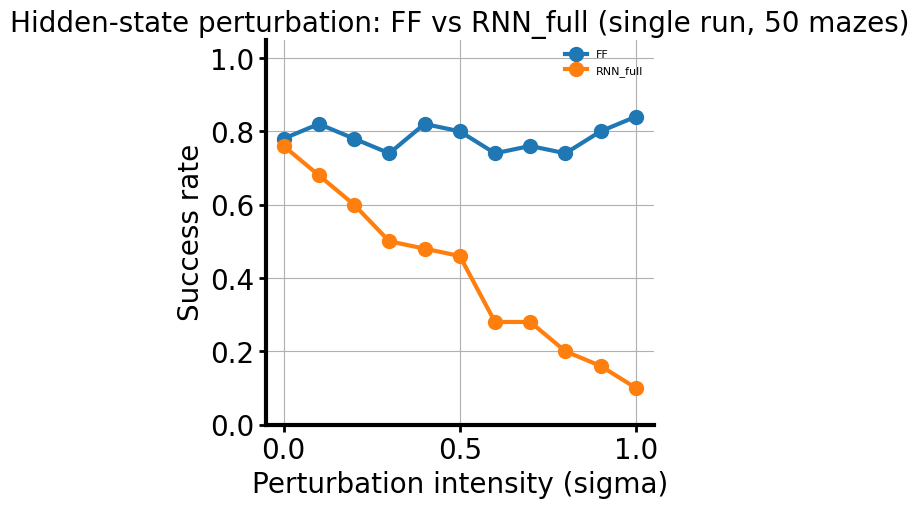

In [56]:
import matplotlib.pyplot as plt

pivot = df_summary.pivot_table(index="sigma", columns="arch", values="success_rate")

plt.figure()
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker="o", label=str(col))

plt.xlabel("Perturbation intensity (sigma)")
plt.ylabel("Success rate")
plt.title("Hidden-state perturbation: FF vs RNN_full (single run, 50 mazes)")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()


In [57]:
pivot = df_summary.pivot_table(index="sigma", columns="arch", values="success_rate").sort_index()

def half_success_crossover(curve_x, curve_y, threshold=0.5):
    """Linearly interpolate where curve_y crosses `threshold` (descending)."""
    below = np.where(curve_y < threshold)[0]
    if len(below) == 0:
        return None  # never crosses
    k = below[0]
    if k == 0:
        return None  # already below at sigma=0; can't interpolate
    x0, x1 = curve_x[k - 1], curve_x[k]
    y0, y1 = curve_y[k - 1], curve_y[k]
    return x0 + (threshold - y0) * (x1 - x0) / (y1 - y0)

x = pivot.index.values
for col in pivot.columns:
    y = pivot[col].values
    crossing = half_success_crossover(x, y)
    if crossing is None:
        print(f"{col}: does not cross 50% in tested sigma range (max={x[-1]})")
    else:
        print(f"{col}: drops below 50% success at sigma = {crossing:.3f}")


FF: does not cross 50% in tested sigma range (max=1.0)
RNN_full: drops below 50% success at sigma = 0.300


RNN_full drops below 50% success at σ ≈ 0.343
FF does not cross 50% in the tested range (σ ≤ 1.0)

### Interpretation: robustness curve for a single trained agent

The success-rate curve remains relatively flat for small perturbations
(σ ≤ 0.1) and exhibits only a modest decline at higher noise levels
(σ = 0.2–0.3).

This indicates that the agent’s internal dynamics are resilient to transient
hidden-state perturbations. Rather than failing catastrophically, performance
degrades gradually, suggesting the presence of stable attractor dynamics that
allow recovery after perturbation.




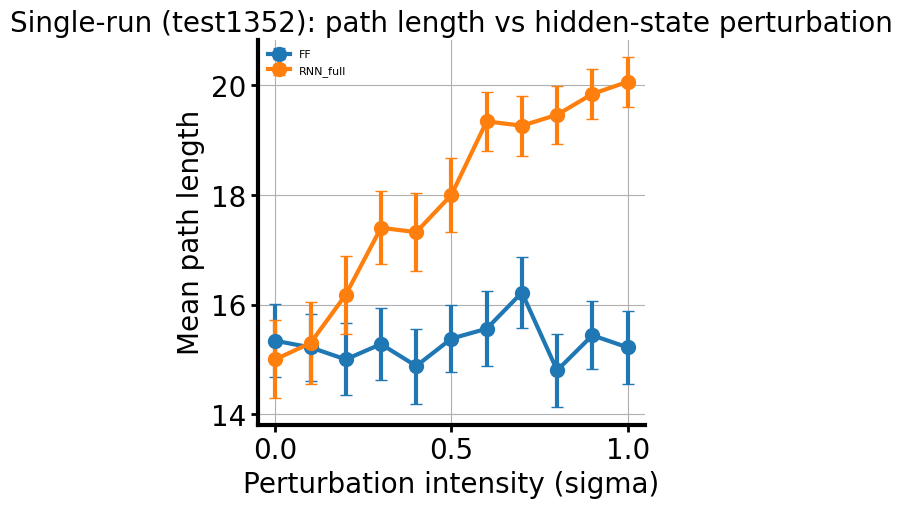

In [58]:
plt.figure()

pivot_len = df_summary.pivot_table(index="sigma", columns="arch", values="mean_path_len")
pivot_sem = df_summary.pivot_table(index="sigma", columns="arch", values="sem_path_len")

for col in pivot_len.columns:
    plt.errorbar(
        pivot_len.index, pivot_len[col],
        yerr=pivot_sem[col],
        marker="o", capsize=4, label=str(col),
    )

plt.xlabel("Perturbation intensity (sigma)")
plt.ylabel("Mean path length")
plt.title("Single-run (test1352): path length vs hidden-state perturbation")
plt.grid(True)
plt.legend()
plt.show()


### Interpretation: navigation efficiency under perturbation

Mean path length increases monotonically with perturbation intensity,
indicating that stronger hidden-state disruptions lead to less efficient
navigation.

Importantly, the increase is gradual rather than abrupt, suggesting that
perturbations impair internal planning or coordination without destabilising
the agent’s policy. Combined with the relatively stable success rate, this
pattern reflects robust recovery dynamics: the agent remains goal-directed
but requires additional corrective actions following perturbation.


## Part 3 - Scaling up to test1351–test1400

Now that the perturbation protocol is validated on a single agent, we apply the
same sweep across a cohort of trained agents from runs test1351 to test1400.

For consistency and fair comparison, we:
- use the same fixed subset of mazes (first 50)
- use the same perturbation timing and duration (onset=8, duration=3)
- sweep the same sigma values

We store one robustness curve per run and then summarise across runs.


In [59]:
# --- Architecture label helper (mirrors architecture_registry.py) -----------
# Derive a model's architecture label from its OWN stored wm_flags, so labels
# can never be silently wrong. If you have the registry on your path, prefer:
#     from architecture_registry import architecture_from_agent
import numpy as np

_FLAG_NAMES = ["ii", "hh", "oo", "io", "oi", "hi", "oh"]

def arch_label_from_agent(a):
    """wm_flags -> canonical label: 'FF', 'RNN_full', or e.g. 'hh+hi'."""
    flags = np.asarray(a.wm_flags).astype(int)
    if flags.sum() == 0:
        return "FF"
    if flags.sum() == 7:
        return "RNN_full"
    return "+".join(n for n, b in zip(_FLAG_NAMES, flags) if b)


In [60]:
from pathlib import Path
import pickle
import pandas as pd
import numpy as np

# ------------------------
# Part 3: Cohort sweep (test1351-test1400)
# Uses 128.pickle from each run when available, otherwise falls back to the
# first .pickle in the folder. Tags each row with run name, agent file, and
# wm_flags for later grouping.
# ------------------------

RESULTS_DIR = Path("/Users/lakshaasrishankar/Documents/Important Documents /Dr Marcus Ghosh Project/datasets/pRNN_data")

RUN_IDS = range(1351, 1401)  # 1351-1400 inclusive
RUN_DIRS = [RESULTS_DIR / f"test{rid}" for rid in RUN_IDS]

cohort_sigmas = list(np.linspace(0.0, 1.0, 11))
MAZE_IDX = list(range(50))

all_per_trial = []
skipped_runs = []

for run_dir in RUN_DIRS:
    if not run_dir.exists():
        skipped_runs.append((run_dir.name, "folder not found"))
        continue

    agent_files = sorted(run_dir.glob("*.pickle"))
    if not agent_files:
        skipped_runs.append((run_dir.name, "no .pickle files found"))
        continue

    preferred_agent = run_dir / "128.pickle"
    agent_path = preferred_agent if preferred_agent.exists() else agent_files[0]

    try:
        with open(agent_path, "rb") as f:
            a = pickle.load(f)
    except Exception as e:
        skipped_runs.append((run_dir.name, f"failed to load {agent_path.name}: {e}"))
        continue

    # Wrap the single agent in the agents-dict shape that the sweep expects.
    agent_id_int = int(agent_path.stem)  # "128" -> 128
    arch_label = arch_label_from_agent(a)  # derive from wm_flags, never hardcode
    one_agent = {agent_id_int: {"obj": a, "arch": arch_label}}

    try:
        df = run_hidden_perturb_sweep_per_trial(
            agents=one_agent,
            maze_obj=maze,
            maze_indices=MAZE_IDX,
            sigmas=cohort_sigmas,
            onset=0,
            duration=20,
            n_steps=20,
            seed=0,
        )
    except Exception as e:
        skipped_runs.append((run_dir.name, f"sweep failed: {e}"))
        continue

    df["run"] = run_dir.name
    df["agent_file"] = agent_path.name
    try:
        df["wm_flags"] = str(getattr(a, "wm_flags", None))
    except Exception:
        df["wm_flags"] = None

    all_per_trial.append(df)

if not all_per_trial:
    from collections import Counter
    print("All runs skipped. Reason categories:",
          dict(Counter(str(r).split(":")[0] for _, r in skipped_runs)))
    for name, reason in skipped_runs[:5]:
        print("  ", name, "->", reason)
    raise RuntimeError("No runs produced results -- see skip reasons printed above.")

df_cohort_per_trial = pd.concat(all_per_trial, ignore_index=True)

print("Rows:", len(df_cohort_per_trial))
print("Runs included:", df_cohort_per_trial["run"].nunique())
if skipped_runs:
    print(f"Skipped runs: {len(skipped_runs)}")
    print("First 5 skipped:", skipped_runs[:5])

df_cohort_per_trial.head()


Rows: 27500
Runs included: 50


,agent_id,arch,locus,sigma,maze_idx,success,path_len,end_time,run,agent_file,wm_flags
0,128,RNN_full,hidden,0.0,0,0,21,19,test1351,128.pickle,[1 1 1 1 1 1 1]
1,128,RNN_full,hidden,0.0,1,1,7,5,test1351,128.pickle,[1 1 1 1 1 1 1]
2,128,RNN_full,hidden,0.0,2,1,11,9,test1351,128.pickle,[1 1 1 1 1 1 1]
3,128,RNN_full,hidden,0.0,3,1,13,11,test1351,128.pickle,[1 1 1 1 1 1 1]
4,128,RNN_full,hidden,0.0,4,0,21,19,test1351,128.pickle,[1 1 1 1 1 1 1]


## 3.1 Cohort robustness summary (test1351–test1400)

We now aggregate across all 50 runs to obtain a cohort-level robustness curve.
For each sigma, we compute:
- mean success rate ± SEM across runs
- mean path length ± SEM across runs
- mean time ± SEM across runs



In [61]:
import numpy as np

# Step 1: per-run summary -- average across the 50 mazes for each (run, sigma)
per_run = (
    df_cohort_per_trial
    .groupby(["run", "sigma"], as_index=False)
    .agg(
        run_success_rate=("success", "mean"),
        run_mean_path_len=("path_len", "mean"),
        run_mean_time=("end_time", "mean"),
    )
)

# Step 2: cohort summary -- mean +/- SD across runs for each sigma
summary = (
    per_run
    .groupby("sigma", as_index=False)
    .agg(
        mean_success=("run_success_rate", "mean"),
        std_success=("run_success_rate", "std"),
        mean_path_len=("run_mean_path_len", "mean"),
        std_path_len=("run_mean_path_len", "std"),
        mean_time=("run_mean_time", "mean"),
        std_time=("run_mean_time", "std"),
        n_runs=("run_success_rate", "count"),
    )
)

summary["sem_success"]  = summary["std_success"]  / np.sqrt(summary["n_runs"])
summary["sem_path_len"] = summary["std_path_len"] / np.sqrt(summary["n_runs"])
summary["sem_time"]     = summary["std_time"]     / np.sqrt(summary["n_runs"])

summary


,sigma,mean_success,std_success,mean_path_len,std_path_len,mean_time,std_time,n_runs,sem_success,sem_path_len,sem_time
0,0.0,0.7432,0.088651,15.0724,0.650361,13.0724,0.650361,50,0.012537,0.091975,0.091975
1,0.1,0.6856,0.086477,15.4780,0.629094,13.4780,0.629094,50,0.012230,0.088967,0.088967
2,0.2,0.5824,0.113902,16.3976,0.961467,14.3976,0.961467,50,0.016108,0.135972,0.135972
3,0.3,0.4556,0.120495,17.4100,1.028875,15.4100,1.028875,50,0.017041,0.145505,0.145505
4,0.4,0.3480,0.112920,18.2900,0.915715,16.2900,0.915715,50,0.015969,0.129502,0.129502
5,0.5,0.2688,0.102631,18.8144,0.790598,16.8144,0.790598,50,0.014514,0.111807,0.111807
6,0.6,0.2248,0.091835,19.1940,0.747461,17.1940,0.747461,50,0.012987,0.105707,0.105707
7,0.7,0.1912,0.089822,19.4872,0.693312,17.4872,0.693312,50,0.012703,0.098049,0.098049
8,0.8,0.1540,0.074969,19.7396,0.647513,17.7396,0.647513,50,0.010602,0.091572,0.091572
9,0.9,0.1380,0.066792,19.8864,0.618021,17.8864,0.618021,50,0.009446,0.087401,0.087401


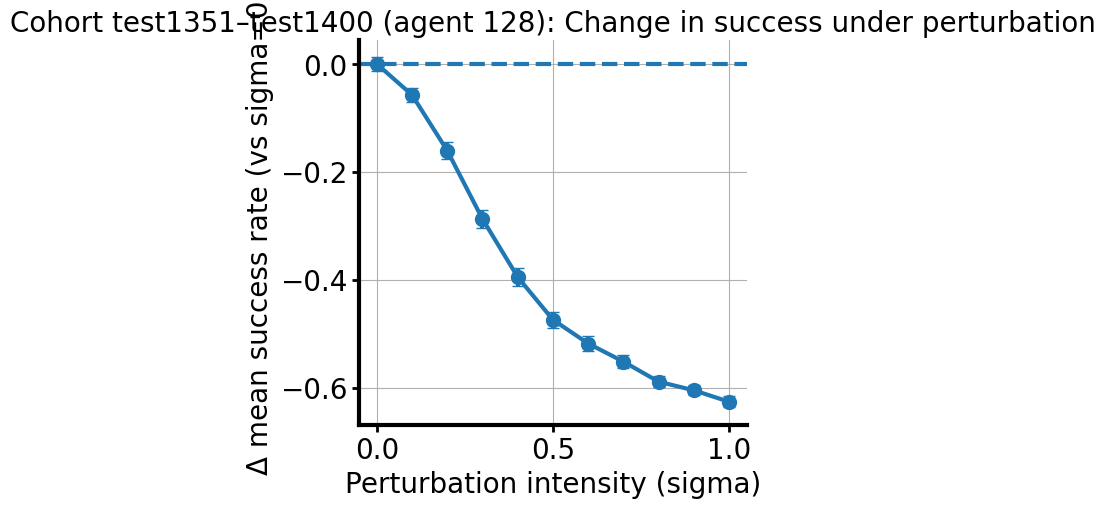

In [62]:
import matplotlib.pyplot as plt

baseline = summary.loc[summary["sigma"] == 0.0, "mean_success"].values[0]
summary["delta_success"] = summary["mean_success"] - baseline

plt.figure()
plt.errorbar(summary["sigma"], summary["delta_success"], yerr=summary["sem_success"], marker="o", capsize=4)
plt.axhline(0, linestyle="--")
plt.xlabel("Perturbation intensity (sigma)")
plt.ylabel("Δ mean success rate (vs sigma=0)")
plt.title("Cohort test1351–test1400 (agent 128): Change in success under perturbation")
plt.grid(True)
plt.show()


### Interpretation: cohort-level robustness to hidden-state perturbations

Across 50 independent runs, performance remains stable for small perturbation
intensities (σ ≤ 0.1), indicating strong robustness of the internal dynamics.
At higher perturbation levels (σ = 0.2–0.3), mean success rate decreases
gradually, with the largest drop observed at σ = 0.3.

The absence of abrupt performance collapse and the smooth degradation profile
suggest that the agents’ recurrent dynamics support recovery following transient
disruptions, consistent with stable attractor-based representations rather than
fragile trajectory-following behaviour.


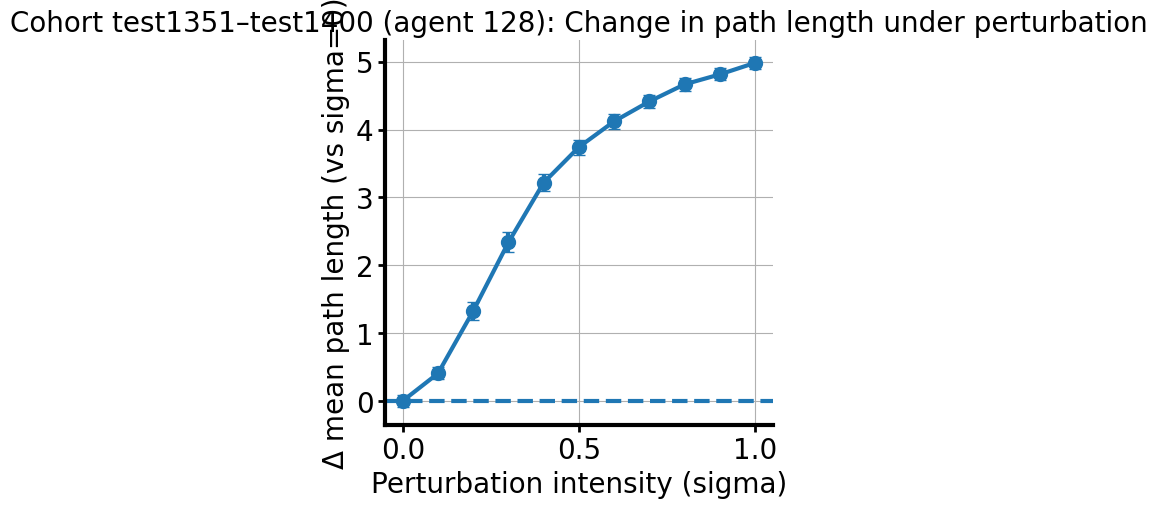

In [63]:
baseline_pl = summary.loc[summary["sigma"] == 0.0, "mean_path_len"].values[0]
summary["delta_path_len"] = summary["mean_path_len"] - baseline_pl

plt.figure()
plt.errorbar(summary["sigma"], summary["delta_path_len"], yerr=summary["sem_path_len"], marker="o", capsize=4)
plt.axhline(0, linestyle="--")
plt.xlabel("Perturbation intensity (sigma)")
plt.ylabel("Δ mean path length (vs sigma=0)")
plt.title("Cohort test1351–test1400 (agent 128): Change in path length under perturbation")
plt.grid(True)
plt.show()


### Interpretation: efficiency costs of recovery under perturbation

While overall task success remains relatively stable under weak perturbations,
mean path length increases monotonically with perturbation intensity. This
indicates that stronger hidden-state disruptions impair navigation efficiency,
leading to longer and less direct trajectories.

Importantly, the absence of abrupt increases or highly variable behaviour
suggests that perturbations do not destabilise the policy, but instead introduce
transient inefficiencies that are gradually corrected over time.


In [64]:
df_cohort_per_trial["wm_flags"].value_counts()


wm_flags
[1 1 1 1 1 1 1]    27500
Name: count, dtype: int64

In [65]:
from pathlib import Path
results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

df_cohort_per_trial.to_csv(results_dir / "cohort_per_trial_gauss_onset0_dur20.csv", index=False)
summary.to_csv(results_dir / "cohort_summary_gauss_onset0_dur20.csv", index=False)
print(f"Saved to {results_dir.resolve()}")

Saved to /Users/lakshaasrishankar/Documents/Important Documents /Dr Marcus Ghosh Project/Multimodal_mazes/results


In [66]:
# Peek at the wm_flags encoding: load powers-of-two architectures and a few
# others from test1352, print their wm_flags vectors. This tells us how
# the integer filename maps to the 7-bit recurrence flag pattern.

from pathlib import Path
import pickle

PEEK_RUN_DIR = RESULTS_DIR / "test1352"
peek_ids = [1, 2, 3, 4, 5, 8, 9, 16, 17, 32, 64, 65, 127, 128]

print(f"{'id':>4}  {'wm_flags':<20}  {'sum(flags)':>10}")
print("-" * 40)
for aid in peek_ids:
    p = PEEK_RUN_DIR / f"{aid}.pickle"
    if not p.exists():
        print(f"{aid:>4}  (file not found)")
        continue
    with open(p, "rb") as f:
        a = pickle.load(f)
    flags = a.wm_flags
    print(f"{aid:>4}  {str(flags):<20}  {int(flags.sum()):>10}")

  id  wm_flags              sum(flags)
----------------------------------------
   1  [0 0 0 0 0 0 0]                0
   2  [0 0 0 0 0 0 1]                1
   3  [0 0 0 0 0 1 0]                1
   4  [0 0 0 0 0 1 1]                2
   5  [0 0 0 0 1 0 0]                1
   8  [0 0 0 0 1 1 1]                3
   9  [0 0 0 1 0 0 0]                1
  16  [0 0 0 1 1 1 1]                4
  17  [0 0 1 0 0 0 0]                1
  32  [0 0 1 1 1 1 1]                5
  64  [0 1 1 1 1 1 1]                6
  65  [1 0 0 0 0 0 0]                1
 127  [1 1 1 1 1 1 0]                6
 128  [1 1 1 1 1 1 1]                7


In [67]:
# ============================================================
# Part 3.5: Architecture sweep
# Same cohort (test1351-test1400), same sigmas, same mazes, same seed --
# but now we loop over 5 architectures spanning FF -> full-recurrent.
# ============================================================

from pathlib import Path
import pickle
import pandas as pd
import numpy as np

# CORRECTED ids/labels (verified against architecture_registry / wm_flags):
#   id 0   wm 0000000  FF        (8 hidden -- capacity-matched to the recurrent archs)
#   id 33  wm 0100000  hh        (hidden->hidden recurrence only; "vanilla RNN")
#   id 3   wm 0000010  hi        (hidden->input feedback only)
#   id 35  wm 0100010  hh+hi     (recurrence + feedback)
#   id 128 wm 1111111  RNN_full  (all 7 weight matrices)
# NB: the previous version swapped id 3 and id 33, and used id 1 (a 34-hidden
# FF) which confounded architecture with capacity. id 0 is the 8-hidden FF.
ARCHITECTURES = [
    {"agent_id": 0,   "label": "FF",       "desc": "Feedforward, 8 hidden (matched)"},
    {"agent_id": 33,  "label": "hh",       "desc": "Hidden->hidden recurrence (vanilla RNN)"},
    {"agent_id": 3,   "label": "hi",       "desc": "Hidden->input feedback only"},
    {"agent_id": 35,  "label": "hh+hi",    "desc": "Recurrence + hidden->input feedback"},
    {"agent_id": 128, "label": "RNN_full", "desc": "All 7 weight matrices on"},
]

ARCH_RUN_IDS  = range(1351, 1401)   # full cohort
ARCH_SIGMAS   = list(np.linspace(0.0, 1.0, 11))
ARCH_MAZE_IDX = list(range(50))
ARCH_ONSET    = 0
ARCH_DURATION = 20
ARCH_N_STEPS  = 20

all_arch_dfs = []
arch_skipped = []

for cfg in ARCHITECTURES:
    aid     = cfg["agent_id"]
    label   = cfg["label"]
    print(f"\n=== Architecture {aid} ({label}) ===")

    one_arch_dfs = []

    for rid in ARCH_RUN_IDS:
        run_dir = RESULTS_DIR / f"test{rid}"
        agent_path = run_dir / f"{aid}.pickle"

        if not agent_path.exists():
            arch_skipped.append((aid, label, run_dir.name, "missing pickle"))
            continue

        try:
            with open(agent_path, "rb") as f:
                a = pickle.load(f)
        except Exception as e:
            arch_skipped.append((aid, label, run_dir.name, f"load failed: {e}"))
            continue

        # Verify the loaded model IS the intended architecture (bible check)
        actual = arch_label_from_agent(a)
        assert actual == label, (
            f"{run_dir.name}/{aid}.pickle is {actual}, expected {label}"
        )
        one_agent = {aid: {"obj": a, "arch": label}}

        try:
            df_one = run_hidden_perturb_sweep_per_trial(
                agents=one_agent,
                maze_obj=maze,
                maze_indices=ARCH_MAZE_IDX,
                sigmas=ARCH_SIGMAS,
                onset=ARCH_ONSET,
                duration=ARCH_DURATION,
                n_steps=ARCH_N_STEPS,
                seed=0,
            )
        except Exception as e:
            arch_skipped.append((aid, label, run_dir.name, f"sweep failed: {e}"))
            continue

        df_one["run"]         = run_dir.name
        df_one["agent_file"]  = agent_path.name
        df_one["arch_label"]  = label
        df_one["wm_flags"]    = str(getattr(a, "wm_flags", None))

        one_arch_dfs.append(df_one)

    if one_arch_dfs:
        df_this_arch = pd.concat(one_arch_dfs, ignore_index=True)
        all_arch_dfs.append(df_this_arch)
        print(f"  {label}: {len(df_this_arch)} trials across {df_this_arch['run'].nunique()} runs")

if not all_arch_dfs:
    raise RuntimeError("No architectures produced results.")

df_arch_sweep = pd.concat(all_arch_dfs, ignore_index=True)

print(f"\n--- Total rows: {len(df_arch_sweep)}")
print(f"--- Architectures present: {df_arch_sweep['arch_label'].unique().tolist()}")
print(f"--- Runs per architecture: {df_arch_sweep.groupby('arch_label')['run'].nunique().to_dict()}")
if arch_skipped:
    print(f"--- Skipped: {len(arch_skipped)} (arch, run) combos")
    print(f"    First 5: {arch_skipped[:5]}")


=== Architecture 0 (FF) ===
  FF: 27500 trials across 50 runs

=== Architecture 33 (hh) ===
  hh: 27500 trials across 50 runs

=== Architecture 3 (hi) ===
  hi: 27500 trials across 50 runs

=== Architecture 35 (hh+hi) ===
  hh+hi: 27500 trials across 50 runs

=== Architecture 128 (RNN_full) ===
  RNN_full: 27500 trials across 50 runs

--- Total rows: 137500
--- Architectures present: ['FF', 'hh', 'hi', 'hh+hi', 'RNN_full']
--- Runs per architecture: {'FF': 50, 'RNN_full': 50, 'hh': 50, 'hh+hi': 50, 'hi': 50}


In [68]:
df_arch_sweep.to_csv(results_dir / "arch_sweep_gauss_onset0_dur20.csv", index=False)
print(f"Saved {len(df_arch_sweep)} rows to {results_dir.resolve()}")

Saved 137500 rows to /Users/lakshaasrishankar/Documents/Important Documents /Dr Marcus Ghosh Project/Multimodal_mazes/results


In [69]:
# Per-run summary first (50 mazes -> one number per (arch, run, sigma))
per_run_arch = (
    df_arch_sweep
    .groupby(["arch_label", "run", "sigma"], as_index=False)
    .agg(
        run_success_rate=("success", "mean"),
        run_mean_path_len=("path_len", "mean"),
    )
)

# Cohort summary: mean +/- SEM across runs, per (arch, sigma)
arch_summary = (
    per_run_arch
    .groupby(["arch_label", "sigma"], as_index=False)
    .agg(
        mean_success=("run_success_rate", "mean"),
        std_success=("run_success_rate", "std"),
        mean_path_len=("run_mean_path_len", "mean"),
        std_path_len=("run_mean_path_len", "std"),
        n_runs=("run_success_rate", "count"),
    )
)
arch_summary["sem_success"]  = arch_summary["std_success"]  / np.sqrt(arch_summary["n_runs"])
arch_summary["sem_path_len"] = arch_summary["std_path_len"] / np.sqrt(arch_summary["n_runs"])

# Compute delta_success per architecture
baseline_per_arch = (
    arch_summary[arch_summary["sigma"] == 0.0]
    .set_index("arch_label")["mean_success"]
)
arch_summary["delta_success"] = arch_summary.apply(
    lambda r: r["mean_success"] - baseline_per_arch[r["arch_label"]],
    axis=1,
)

arch_summary

,arch_label,sigma,mean_success,std_success,mean_path_len,std_path_len,n_runs,sem_success,sem_path_len,delta_success
0,FF,0.0,0.7816,0.056545,15.2816,0.463665,50,0.007997,0.065572,0.0000
1,FF,0.1,0.7708,0.064042,15.3404,0.486797,50,0.009057,0.068843,-0.0108
2,FF,0.2,0.7804,0.065464,15.1684,0.493899,50,0.009258,0.069848,-0.0012
3,FF,0.3,0.7688,0.061167,15.2668,0.507135,50,0.008650,0.071720,-0.0128
4,FF,0.4,0.7744,0.060480,15.2416,0.434038,50,0.008553,0.061382,-0.0072
5,FF,0.5,0.7696,0.068242,15.3652,0.496334,50,0.009651,0.070192,-0.0120
6,FF,0.6,0.7796,0.065089,15.2680,0.489081,50,0.009205,0.069166,-0.0020
7,FF,0.7,0.7740,0.064302,15.2644,0.471633,50,0.009094,0.066699,-0.0076
8,FF,0.8,0.7748,0.062572,15.2912,0.447344,50,0.008849,0.063264,-0.0068
9,FF,0.9,0.7784,0.055378,15.2820,0.444233,50,0.007832,0.062824,-0.0032


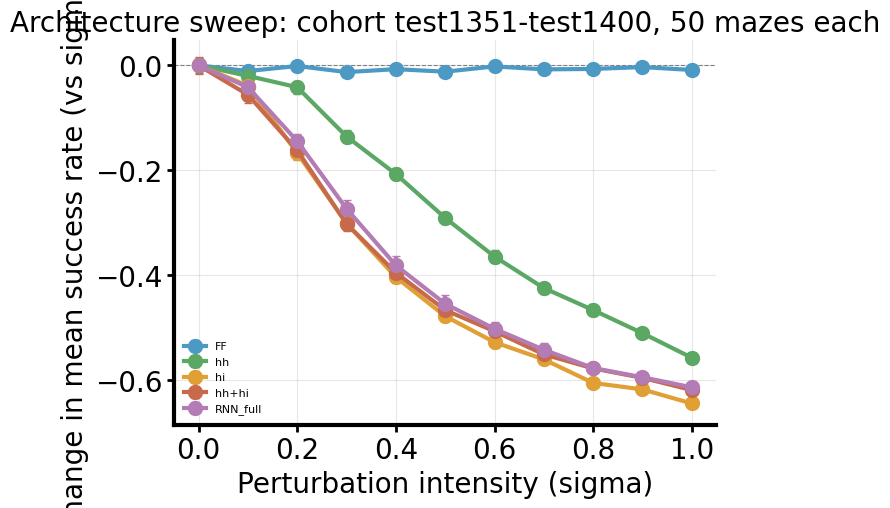

In [70]:
import matplotlib.pyplot as plt

# Stable order from low to high recurrence -- matches the legend reading order
ARCH_ORDER = ["FF", "hh", "hi", "hh+hi", "RNN_full"]
COLOURS = {
    "FF":       "#4C9AC4",  # blue
    "hh":       "#5BA764",  # green
    "hi":       "#E0A035",  # amber
    "hh+hi":    "#C76A4C",  # rust
    "RNN_full": "#B47CB5",  # purple
}

fig, ax = plt.subplots(figsize=(7, 5))

for label in ARCH_ORDER:
    sub = arch_summary[arch_summary["arch_label"] == label].sort_values("sigma")
    if sub.empty:
        continue
    ax.errorbar(
        sub["sigma"], sub["delta_success"],
        yerr=sub["sem_success"],
        marker="o", capsize=3, label=label,
        color=COLOURS.get(label),
    )

ax.axhline(0, ls="--", color="gray", lw=0.8)
ax.set_xlabel("Perturbation intensity (sigma)")
ax.set_ylabel("Change in mean success rate (vs sigma=0)")
ax.set_title("Architecture sweep: cohort test1351-test1400, 50 mazes each")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")
plt.show()

In [71]:
df_arch_sweep.to_csv(results_dir / "arch_sweep_gauss_onset0_dur20.csv", index=False)
arch_summary.to_csv(results_dir / "arch_summary_gauss_onset0_dur20.csv", index=False)
print("Saved.")

Saved.


## Part 4 - Comparing perturbation locus: input vs hidden vs output

Dr Ghosh's suggestion: inject the seizure-like signal at the **input**, the
**hidden** state, and the **output**, and compare. Below we take the two
capacity-matched anchor architectures - feedforward (`id 0`) and full-recurrent
(`id 128`) - and sweep the noise intensity at each locus.

Two predictions this design lets us test directly:
- **input** and **output** perturbation should degrade *both* architectures,
  since neither depends on recurrence.
- **hidden** perturbation should degrade the recurrent agent but leave the
  feedforward agent unchanged (it has no recurrent state to corrupt) - a clean
  positive/negative control that the previous hidden-only design could not show.

This runs across the **full cohort** (test1351-test1400): for every run we load
the FF (`id 0`) and RNN_full (`id 128`) agents, sweep each locus, then summarise
as mean +/- SEM across the 50 runs - the same statistical treatment as the
architecture sweep.


runs included: 50  |  rows: 165000


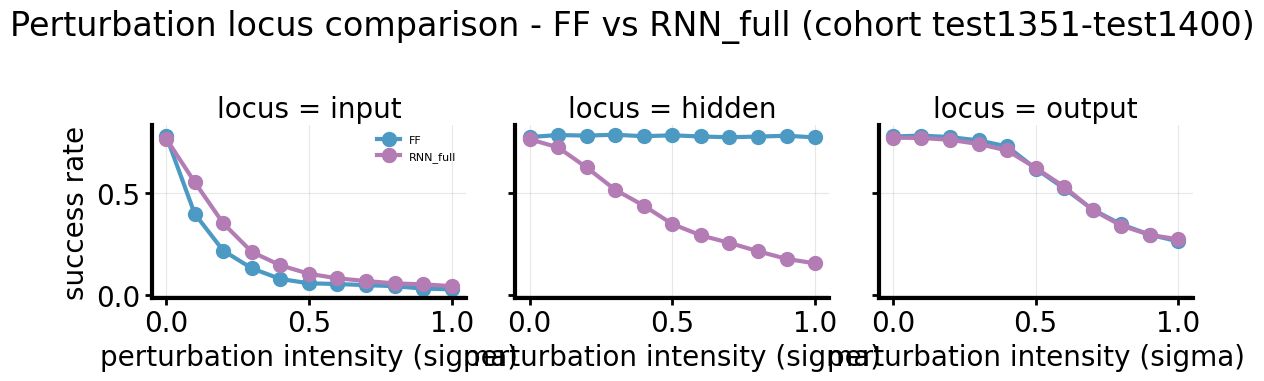

In [165]:
import matplotlib.pyplot as plt
from collections import Counter

# Cohort-wide locus comparison: FF (id 0) vs RNN_full (id 128) across ALL runs,
# perturbing at input / hidden / output. Same sigmas, mazes and seeds throughout.
LOCUS_RUN_IDS  = range(1351, 1401)
LOCUS_SIGMAS   = list(np.linspace(0.0, 1.0, 11))
LOCUS_MAZE_IDX = list(range(50))
LOCI           = ["input", "hidden", "output"]
LOCUS_ANCHORS  = [(0, "FF"), (128, "RNN_full")]

locus_dfs, locus_skipped = [], []

for rid in LOCUS_RUN_IDS:
    run_dir = RESULTS_DIR / f"test{rid}"
    for aid, label in LOCUS_ANCHORS:
        agent_path = run_dir / f"{aid}.pickle"
        if not agent_path.exists():
            locus_skipped.append((run_dir.name, aid, "missing pickle"))
            continue
        try:
            with open(agent_path, "rb") as f:
                a = pickle.load(f)
        except Exception as e:
            locus_skipped.append((run_dir.name, aid, f"load failed: {e}"))
            continue
        # bible check: the loaded model must be the architecture we expect
        assert arch_label_from_agent(a) == label, f"{run_dir.name}/{aid}.pickle is mislabelled"
        for locus in LOCI:
            df = run_hidden_perturb_sweep_per_trial(
                agents={aid: {"obj": a, "arch": label}},
                maze_obj=maze,
                maze_indices=LOCUS_MAZE_IDX,
                sigmas=LOCUS_SIGMAS,
                onset=0, duration=20, n_steps=20,
                locus=locus, seed=0,
            )
            df["run"] = run_dir.name
            locus_dfs.append(df)

if not locus_dfs:
    print("skip reasons:", dict(Counter(r for *_, r in locus_skipped)))
    raise RuntimeError("Locus sweep produced no results -- see reasons above.")

df_locus = pd.concat(locus_dfs, ignore_index=True)

# per-run mean (50 mazes -> one number per run), then mean +/- SEM across runs
per_run_locus = (
    df_locus.groupby(["arch", "locus", "run", "sigma"], as_index=False)
            .agg(run_success=("success", "mean"))
)
locus_summary = (
    per_run_locus.groupby(["arch", "locus", "sigma"], as_index=False)
                 .agg(mean_success=("run_success", "mean"),
                      std_success=("run_success", "std"),
                      n_runs=("run_success", "count"))
)
locus_summary["sem_success"] = locus_summary["std_success"] / np.sqrt(locus_summary["n_runs"])

if locus_skipped:
    print(f"skipped {len(locus_skipped)} (run, agent) combos; first few: {locus_skipped[:3]}")
print(f"runs included: {df_locus['run'].nunique()}  |  rows: {len(df_locus)}")

COL = {"FF": "#4C9AC4", "RNN_full": "#B47CB5"}
fig, axes = plt.subplots(1, len(LOCI), figsize=(4 * len(LOCI), 4), sharey=True)
for ax, locus in zip(axes, LOCI):
    sub = locus_summary[locus_summary["locus"] == locus]
    for arch in ["FF", "RNN_full"]:
        s = sub[sub["arch"] == arch].sort_values("sigma")
        ax.errorbar(s["sigma"], s["mean_success"], yerr=s["sem_success"],
                    marker="o", capsize=3, label=arch, color=COL[arch])
    ax.set_title(f"locus = {locus}")
    ax.set_xlabel("perturbation intensity (sigma)")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("success rate")
axes[0].legend()
plt.suptitle("Perturbation locus comparison - FF vs RNN_full (cohort test1351-test1400)")
plt.tight_layout()
plt.show()


## Part 5 - Seizure-like perturbation modes

So far every perturbation has been zero-mean white Gaussian noise. A seizure is
not white noise - it is high-amplitude, often rhythmic, and can drive neurons
into sustained depolarisation. Here we compare five perturbation *modes* at the
**hidden** locus (the recurrence-specific axis from Part 4) on the RNN_full
agent across the full cohort:

- **gaussian**   - white noise (the baseline we have used so far)
- **drift**      - a fixed coherent push (tonic depolarisation)
- **oscillatory**- a rhythmic, epileptiform sine component
- **burst**      - the window's whole energy in one transient at onset
- **clamp**      - the hidden state pinned to a saturated pattern (depolarisation
                   block / information destruction)

The four additive modes share a per-step RMS budget set by `sigma`, so they are
directly comparable; `clamp` overwrites the state, so its `sigma` axis is a
magnitude rather than matched energy (read it as a separate failure mode). The
question is whether *structure* matters: at equal budget, does a coherent or
rhythmic perturbation disrupt navigation more than white noise?


runs included: 50 | rows: 137500


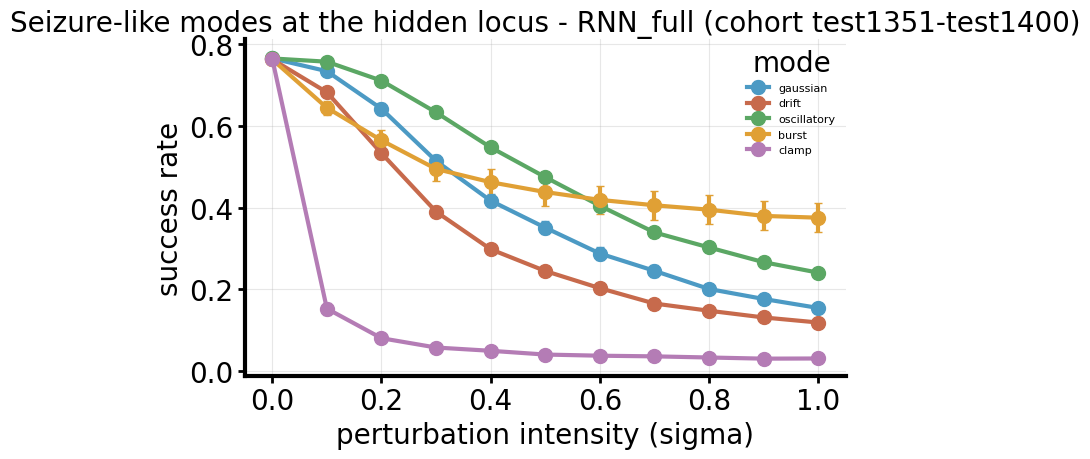

In [166]:
import matplotlib.pyplot as plt
from collections import Counter

# Seizure-mode comparison: RNN_full (id 128), hidden locus, full cohort.
MODE_RUN_IDS  = range(1351, 1401)
MODE_SIGMAS   = list(np.linspace(0.0, 1.0, 11))
MODE_MAZE_IDX = list(range(50))
MODES         = ["gaussian", "drift", "oscillatory", "burst", "clamp"]
MODE_AID, MODE_LABEL = 128, "RNN_full"
MODE_LOCUS    = "hidden"

mode_dfs, mode_skipped = [], []
for rid in MODE_RUN_IDS:
    run_dir = RESULTS_DIR / f"test{rid}"
    agent_path = run_dir / f"{MODE_AID}.pickle"
    if not agent_path.exists():
        mode_skipped.append((run_dir.name, "missing")); continue
    with open(agent_path, "rb") as f:
        a = pickle.load(f)
    assert arch_label_from_agent(a) == MODE_LABEL, f"{run_dir.name} mislabelled"
    for mode in MODES:
        df = run_hidden_perturb_sweep_per_trial(
            agents={MODE_AID: {"obj": a, "arch": MODE_LABEL}},
            maze_obj=maze, maze_indices=MODE_MAZE_IDX,
            sigmas=MODE_SIGMAS, onset=0, duration=20, n_steps=20,
            locus=MODE_LOCUS, mode=mode, seed=0,
        )
        df["run"] = run_dir.name
        mode_dfs.append(df)

df_modes = pd.concat(mode_dfs, ignore_index=True)

per_run_mode = (
    df_modes.groupby(["mode", "run", "sigma"], as_index=False)
            .agg(run_success=("success", "mean"))
)
mode_summary = (
    per_run_mode.groupby(["mode", "sigma"], as_index=False)
                .agg(mean_success=("run_success", "mean"),
                     std_success=("run_success", "std"),
                     n_runs=("run_success", "count"))
)
mode_summary["sem_success"] = mode_summary["std_success"] / np.sqrt(mode_summary["n_runs"])

print(f"runs included: {df_modes['run'].nunique()} | rows: {len(df_modes)}")

MODE_COL = {"gaussian":"#4C9AC4", "drift":"#C76A4C", "oscillatory":"#5BA764",
            "burst":"#E0A035", "clamp":"#B47CB5"}
fig, ax = plt.subplots(figsize=(7.5, 5))
for mode in MODES:
    s = mode_summary[mode_summary["mode"] == mode].sort_values("sigma")
    ax.errorbar(s["sigma"], s["mean_success"], yerr=s["sem_success"],
                marker="o", capsize=3, label=mode, color=MODE_COL[mode])
ax.set_xlabel("perturbation intensity (sigma)")
ax.set_ylabel("success rate")
ax.set_title("Seizure-like modes at the hidden locus - RNN_full (cohort test1351-test1400)")
ax.grid(True, alpha=0.3)
ax.legend(title="mode")
plt.tight_layout()
plt.show()


## Part 6 - Does oscillatory gentleness depend on frequency?

In Part 5 the oscillatory mode (default `freq=0.25`, one cycle per 4 steps) was
among the *gentlest* - a fast sine spends much of each cycle near zero and
reverses sign, so at matched energy its pull self-cancels. The prediction is
that a *slow* oscillation (≈ one cycle over the whole 20-step window) should
behave more like a coherent drift and be far more destructive. Here we sweep
`freq` for the oscillatory mode at a fixed intensity, with gaussian and drift at
the same intensity as reference lines (the incoherent and fully-coherent limits).


runs included: 50 | sigma = 0.5


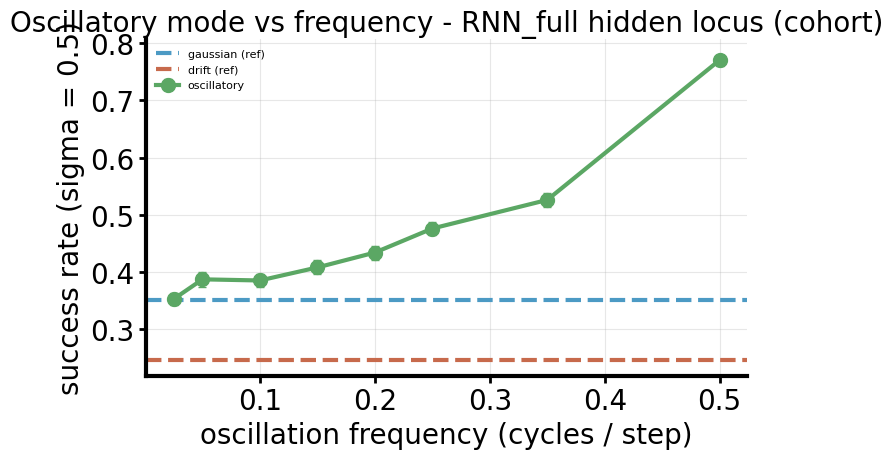

In [167]:
import matplotlib.pyplot as plt

FREQ_RUN_IDS  = range(1351, 1401)
FREQS         = [0.025, 0.05, 0.10, 0.15, 0.20, 0.25, 0.35, 0.50]
FREQ_SIGMA    = 0.5                      # fixed intensity for the frequency sweep
FREQ_MAZE_IDX = list(range(50))
FREQ_AID, FREQ_LABEL = 128, "RNN_full"

def _per_run_success(df):
    return (df.groupby("run", as_index=False)
              .agg(run_success=("success", "mean")))

osc_rows, ref_rows = [], []
for rid in FREQ_RUN_IDS:
    run_dir = RESULTS_DIR / f"test{rid}"
    with open(run_dir / f"{FREQ_AID}.pickle", "rb") as f:
        a = pickle.load(f)
    assert arch_label_from_agent(a) == FREQ_LABEL
    # oscillatory at each frequency
    for fr in FREQS:
        df = run_hidden_perturb_sweep_per_trial(
            agents={FREQ_AID: {"obj": a, "arch": FREQ_LABEL}},
            maze_obj=maze, maze_indices=FREQ_MAZE_IDX, sigmas=[FREQ_SIGMA],
            onset=0, duration=20, n_steps=20, locus="hidden",
            mode="oscillatory", freq=fr, seed=0,
        )
        osc_rows.append({"run": run_dir.name, "freq": fr,
                         "success": df["success"].mean()})
    # gaussian + drift reference (frequency-independent)
    for ref_mode in ["gaussian", "drift"]:
        df = run_hidden_perturb_sweep_per_trial(
            agents={FREQ_AID: {"obj": a, "arch": FREQ_LABEL}},
            maze_obj=maze, maze_indices=FREQ_MAZE_IDX, sigmas=[FREQ_SIGMA],
            onset=0, duration=20, n_steps=20, locus="hidden",
            mode=ref_mode, seed=0,
        )
        ref_rows.append({"run": run_dir.name, "mode": ref_mode,
                         "success": df["success"].mean()})

df_osc = pd.DataFrame(osc_rows)
df_ref = pd.DataFrame(ref_rows)

osc_summary = (df_osc.groupby("freq", as_index=False)
               .agg(mean=("success", "mean"), std=("success", "std"),
                    n=("success", "count")))
osc_summary["sem"] = osc_summary["std"] / np.sqrt(osc_summary["n"])
ref_summary = (df_ref.groupby("mode", as_index=False)
               .agg(mean=("success", "mean")))

print(f"runs included: {df_osc['run'].nunique()} | sigma = {FREQ_SIGMA}")

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.errorbar(osc_summary["freq"], osc_summary["mean"], yerr=osc_summary["sem"],
            marker="o", capsize=3, color="#5BA764", label="oscillatory")
for ref_mode, col in [("gaussian", "#4C9AC4"), ("drift", "#C76A4C")]:
    y = ref_summary.loc[ref_summary["mode"] == ref_mode, "mean"].iloc[0]
    ax.axhline(y, ls="--", color=col, label=f"{ref_mode} (ref)")
ax.set_xlabel("oscillation frequency (cycles / step)")
ax.set_ylabel(f"success rate (sigma = {FREQ_SIGMA})")
ax.set_title("Oscillatory mode vs frequency - RNN_full hidden locus (cohort)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Part 7 - Recovery dynamics: does the hidden state re-converge?

Part 5 showed burst and oscillatory plateauing rather than collapsing, hinting
that the recurrent network *recovers* after a transient. Here we make that
explicit. Using a short perturbation window (steps 3-7) instead of the whole
trial, we record the hidden-state trajectory and measure its Euclidean distance
from the unperturbed (baseline) trajectory at each step. The agent's internal
randomness is seeded identically for baseline and perturbed runs, so the
deviation reflects the perturbation alone. A mode that *recovers* returns toward
zero after the window; a mode that *destroys information* (clamp) stays high.


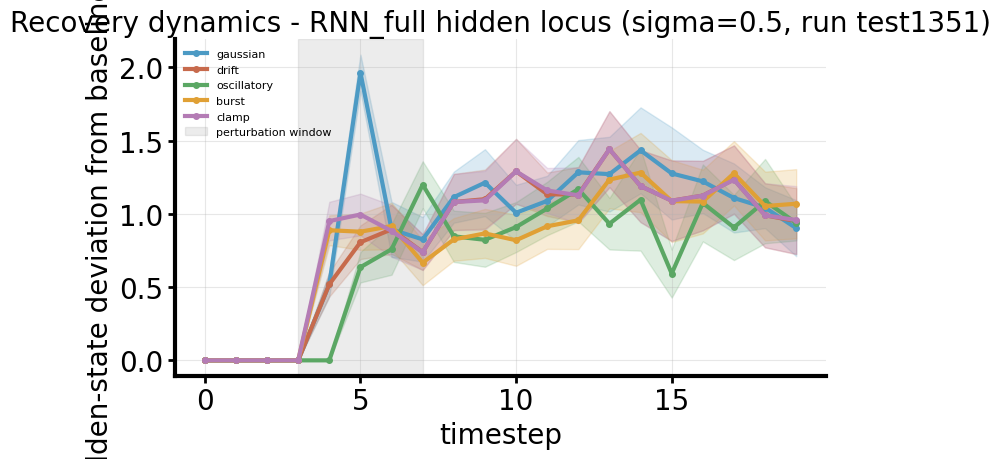

In [168]:
import matplotlib.pyplot as plt

REC_RUN     = RESULTS_DIR / "test1351"
REC_AID     = 128
REC_MODES   = ["gaussian", "drift", "oscillatory", "burst", "clamp"]
REC_SIGMA   = 0.5
REC_ONSET, REC_DURATION, REC_NSTEPS = 3, 5, 20
REC_MAZES   = list(range(20))      # average deviation over several mazes

with open(REC_RUN / f"{REC_AID}.pickle", "rb") as f:
    rec_agent = pickle.load(f)
assert arch_label_from_agent(rec_agent) == "RNN_full"

def hidden_trajectory(agnt, mi, mode, sigma, gseed):
    """Hidden state per step for one maze, with the agent's own RNG seeded."""
    np.random.seed(gseed)
    torch.manual_seed(gseed)
    detach = attach_perturbation_hook(
        agnt, onset=REC_ONSET, duration=REC_DURATION, sigma=sigma,
        locus="hidden", mode=mode, seed=0,
    )
    _, _, states = multimodal_mazes.maze_trial(
        mz=maze.mazes[mi], mz_start_loc=maze.start_locations[mi],
        mz_goal_loc=maze.goal_locations[mi], channels=[1, 1],
        sensor_noise_scale=0.05, drop_connect_p=0.0, n_steps=REC_NSTEPS,
        agnt=agnt, record_states=True,
    )
    detach()
    return np.stack([s[2].numpy() for s in states])   # (n_steps, n_hidden)

# deviation from baseline, averaged over mazes, per mode.
# NOTE: maze_trial stops early when the agent reaches the goal, so baseline and
# perturbed trajectories can have different lengths. Compare over their common
# prefix and pad to REC_NSTEPS with NaN so they aggregate cleanly.
def _padded_dev(base, traj, n):
    L = min(len(base), len(traj))
    d = np.full(n, np.nan)
    d[:L] = np.linalg.norm(traj[:L] - base[:L], axis=1)
    return d

dev = {m: [] for m in REC_MODES}
for mi in REC_MAZES:
    base = hidden_trajectory(rec_agent, mi, "gaussian", 0.0, gseed=mi)  # sigma=0 -> no perturbation
    for mode in REC_MODES:
        traj = hidden_trajectory(rec_agent, mi, mode, REC_SIGMA, gseed=mi)
        dev[mode].append(_padded_dev(base, traj, REC_NSTEPS))

REC_COL = {"gaussian":"#4C9AC4", "drift":"#C76A4C", "oscillatory":"#5BA764",
           "burst":"#E0A035", "clamp":"#B47CB5"}
fig, ax = plt.subplots(figsize=(8, 5))
t = np.arange(REC_NSTEPS)
for mode in REC_MODES:
    d = np.stack(dev[mode])                 # (n_mazes, n_steps), may contain NaN
    cnt = np.sum(~np.isnan(d), axis=0)      # mazes still running at each step
    m = np.nanmean(d, axis=0)
    sem = np.nanstd(d, axis=0) / np.sqrt(np.maximum(cnt, 1))
    valid = cnt > 0
    ax.plot(t[valid], m[valid], marker="o", ms=4, color=REC_COL[mode], label=mode)
    ax.fill_between(t[valid], (m - sem)[valid], (m + sem)[valid],
                    color=REC_COL[mode], alpha=0.2)
ax.axvspan(REC_ONSET, REC_ONSET + REC_DURATION - 1, color="grey", alpha=0.15,
           label="perturbation window")
ax.set_xlabel("timestep")
ax.set_ylabel("hidden-state deviation from baseline (L2)")
ax.set_title(f"Recovery dynamics - RNN_full hidden locus (sigma={REC_SIGMA}, run test1351)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Part 8 - Open-loop recovery: does the hidden state itself re-converge?

Part 7 measured deviation along the agent's *actual* path, which conflates two
things: the hidden state recovering, and the agent walking off onto a different
route (so its inputs diverge too). To isolate the first, we **replay a fixed
input sequence**: we record what the agent sensed on an unperturbed run, then
drive the network with that *same* sequence for both the baseline and the
perturbed run - no sensing, no moving. Now the inputs are identical by
construction, so any hidden-state deviation is purely the perturbation and how
the recurrent dynamics absorb it. Torch is seeded identically for both runs, so
output-feedback noise is shared too.

Prediction: with inputs held fixed, a stable input-driven network should
re-synchronise to the input stream after the perturbation ends. burst (one kick)
should decay fastest; drift/oscillatory decay once the window closes; clamp -
which *overwrites* the state - should take longest, or fail to recover if the
corruption is unrecoverable. This is the diagnostic that separates the modes.


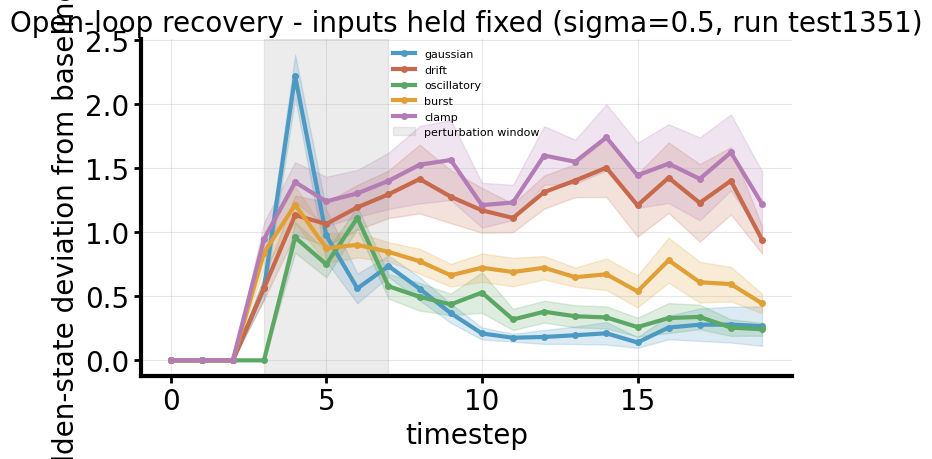

In [169]:
import matplotlib.pyplot as plt

OL_RUN     = RESULTS_DIR / "test1351"
OL_AID     = 128
OL_MODES   = ["gaussian", "drift", "oscillatory", "burst", "clamp"]
OL_SIGMA   = 0.5
OL_ONSET, OL_DURATION, OL_NSTEPS = 3, 5, 20
OL_MAZES   = list(range(20))

with open(OL_RUN / f"{OL_AID}.pickle", "rb") as f:
    ol_agent = pickle.load(f)
assert arch_label_from_agent(ol_agent) == "RNN_full"


def baseline_input_sequence(agnt, mi):
    """Inputs the agent senses on an unperturbed closed-loop run of maze mi."""
    np.random.seed(1000 + mi)
    torch.manual_seed(1000 + mi)
    _, _, states = multimodal_mazes.maze_trial(
        mz=maze.mazes[mi], mz_start_loc=maze.start_locations[mi],
        mz_goal_loc=maze.goal_locations[mi], channels=[1, 1],
        sensor_noise_scale=0.05, drop_connect_p=0.0, n_steps=OL_NSTEPS,
        agnt=agnt, record_states=True,
    )
    shp = agnt.channel_inputs.shape
    return [s[0].numpy().reshape(shp) for s in states]    # 2-D channel_inputs per step


def open_loop_hidden(agnt, input_seq, mode, sigma, seed):
    """Drive the network with a FIXED input sequence (no sense/act); perturb the
    hidden state during the window. Returns the hidden trajectory."""
    torch.manual_seed(seed)
    agnt.prev_input = torch.zeros(agnt.n_input_units)
    agnt.hidden = torch.zeros(agnt.n_hidden_units)
    agnt.prev_output = torch.zeros(agnt.n_output_units)
    rng = np.random.default_rng(0)
    ctx = {}
    H = []
    for t, inp in enumerate(input_seq):
        agnt.channel_inputs = inp.copy()
        if (OL_ONSET <= t < OL_ONSET + OL_DURATION) and sigma > 0:
            tau = t - OL_ONSET
            x = agnt.hidden.detach().numpy().astype(float)
            agnt.hidden = torch.from_numpy(
                apply_perturbation(x, mode, sigma, tau, OL_DURATION, ctx, rng)
            ).float()
        agnt.policy()
        H.append(agnt.hidden.detach().numpy().copy())
    return np.stack(H)


def _pad(d, n):
    out = np.full(n, np.nan)
    out[:len(d)] = d
    return out

ol_dev = {m: [] for m in OL_MODES}
for mi in OL_MAZES:
    seq = baseline_input_sequence(ol_agent, mi)
    base = open_loop_hidden(ol_agent, seq, "gaussian", 0.0, seed=mi)   # no perturbation
    for mode in OL_MODES:
        traj = open_loop_hidden(ol_agent, seq, mode, OL_SIGMA, seed=mi)
        ol_dev[mode].append(_pad(np.linalg.norm(traj - base, axis=1), OL_NSTEPS))

OL_COL = {"gaussian":"#4C9AC4", "drift":"#C76A4C", "oscillatory":"#5BA764",
          "burst":"#E0A035", "clamp":"#B47CB5"}
fig, ax = plt.subplots(figsize=(8, 5))
t = np.arange(OL_NSTEPS)
for mode in OL_MODES:
    d = np.stack(ol_dev[mode])
    cnt = np.sum(~np.isnan(d), axis=0)
    m = np.nanmean(d, axis=0)
    sem = np.nanstd(d, axis=0) / np.sqrt(np.maximum(cnt, 1))
    v = cnt > 0
    ax.plot(t[v], m[v], marker="o", ms=4, color=OL_COL[mode], label=mode)
    ax.fill_between(t[v], (m - sem)[v], (m + sem)[v], color=OL_COL[mode], alpha=0.2)
ax.axvspan(OL_ONSET, OL_ONSET + OL_DURATION - 1, color="grey", alpha=0.15,
           label="perturbation window")
ax.set_xlabel("timestep")
ax.set_ylabel("hidden-state deviation from baseline (L2)")
ax.set_title(f"Open-loop recovery - inputs held fixed (sigma={OL_SIGMA}, run test1351)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Part 9 - Cohort recovery + a recovery metric

Parts 7-8 were a single run; here we put the recovery analysis on the same n=50
footing as Parts 4-6. For every run we load the RNN_full agent, compute the
hidden-state deviation per mode (closed-loop and open-loop), average over mazes
to get one trajectory per run, then summarise as mean +/- SEM across runs.

Two methodological points:
- **Per-agent normalisation.** Different trained agents have different
  hidden-state magnitudes, so before pooling we divide each run's curves by that
  run's own within-window peak (taken across modes). This removes agent scale
  while preserving the ordering *between* modes.
- **A recovery number.** For the open-loop case we report `fraction_recovered`
  = 1 - (deviation at trial end / within-window peak), per run, then mean +/- SEM
  across runs. ~1 means the state returned to baseline; ~0 (or negative) means it
  did not. This turns the recoverer / non-recoverer split into a table.

Requires the functions defined in Parts 7 and 8 (`hidden_trajectory`,
`baseline_input_sequence`, `open_loop_hidden`) - run those cells first.


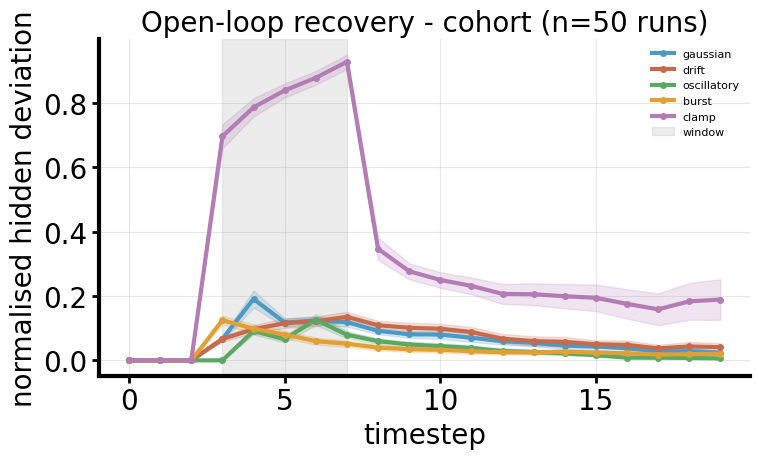

       mode  frac_recovered_mean  frac_recovered_sem  n_runs
oscillatory                0.937               0.025      50
      clamp                0.805               0.064      50
   gaussian                0.802               0.052      50
      burst                0.780               0.060      50
      drift                0.634               0.071      50


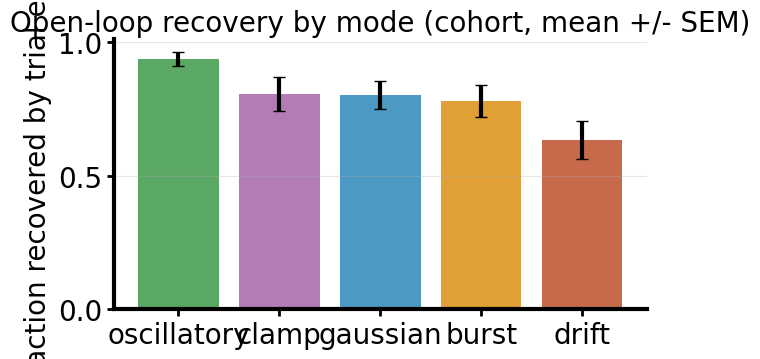

In [170]:
import matplotlib.pyplot as plt

# ---- Cohort OPEN-LOOP recovery (inputs held fixed) + recovery metric ----
COH_RUN_IDS = range(1351, 1401)
COH_MAZES   = list(range(10))            # per run; 50 runs x 10 -> 500 trajectories/mode
COH_MODES   = ["gaussian", "drift", "oscillatory", "burst", "clamp"]
COH_SIGMA   = OL_SIGMA
COH_ONSET, COH_DURATION, COH_NSTEPS = OL_ONSET, OL_DURATION, OL_NSTEPS

def _pad(d, n):
    out = np.full(n, np.nan); out[:len(d)] = d; return out

run_traj = {m: [] for m in COH_MODES}    # per-run normalised mean trajectory
frac_rec = {m: [] for m in COH_MODES}    # per-run fraction recovered (scale-free)

for rid in COH_RUN_IDS:
    with open(RESULTS_DIR / f"test{rid}" / "128.pickle", "rb") as f:
        agnt = pickle.load(f)
    assert arch_label_from_agent(agnt) == "RNN_full"
    per_mode = {m: [] for m in COH_MODES}
    for mi in COH_MAZES:
        seq = baseline_input_sequence(agnt, mi)
        base = open_loop_hidden(agnt, seq, "gaussian", 0.0, seed=mi)
        for m in COH_MODES:
            traj = open_loop_hidden(agnt, seq, m, COH_SIGMA, seed=mi)
            per_mode[m].append(_pad(np.linalg.norm(traj - base, axis=1), COH_NSTEPS))
    run_means = {m: np.nanmean(np.stack(per_mode[m]), axis=0) for m in COH_MODES}
    win = slice(COH_ONSET, COH_ONSET + COH_DURATION)
    scale = max(np.nanmax(run_means[m][win]) for m in COH_MODES)   # per-agent scale
    for m in COH_MODES:
        rm = run_means[m]
        run_traj[m].append(rm / scale)
        peak = np.nanmax(rm[win])
        end = rm[np.where(~np.isnan(rm))[0][-1]]                    # last valid step
        frac_rec[m].append(1.0 - end / peak if peak > 0 else np.nan)

# figure: normalised deviation over time, mean +/- SEM across runs
fig, ax = plt.subplots(figsize=(8, 5))
t = np.arange(COH_NSTEPS)
for m in COH_MODES:
    D = np.stack(run_traj[m])
    cnt = np.sum(~np.isnan(D), axis=0)
    mean = np.nanmean(D, axis=0); sem = np.nanstd(D, axis=0) / np.sqrt(np.maximum(cnt, 1))
    v = cnt > 0
    ax.plot(t[v], mean[v], marker="o", ms=4, color=OL_COL[m], label=m)
    ax.fill_between(t[v], (mean - sem)[v], (mean + sem)[v], color=OL_COL[m], alpha=0.2)
ax.axvspan(COH_ONSET, COH_ONSET + COH_DURATION - 1, color="grey", alpha=0.15, label="window")
ax.set_xlabel("timestep"); ax.set_ylabel("normalised hidden deviation")
ax.set_title(f"Open-loop recovery - cohort (n={len(run_traj['gaussian'])} runs)")
ax.grid(True, alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

# recovery table + bar chart: fraction recovered, mean +/- SEM across runs
rows = []
for m in COH_MODES:
    fr = np.array(frac_rec[m], float); fr = fr[~np.isnan(fr)]
    rows.append({"mode": m, "frac_recovered_mean": round(float(fr.mean()), 3),
                 "frac_recovered_sem": round(float(fr.std() / np.sqrt(len(fr))), 3),
                 "n_runs": len(fr)})
recovery_table = pd.DataFrame(rows).sort_values("frac_recovered_mean", ascending=False)
print(recovery_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
rt = recovery_table
ax.bar(rt["mode"], rt["frac_recovered_mean"],
       yerr=rt["frac_recovered_sem"], capsize=4,
       color=[OL_COL[m] for m in rt["mode"]])
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("fraction recovered by trial end")
ax.set_title("Open-loop recovery by mode (cohort, mean +/- SEM)")
ax.grid(True, axis="y", alpha=0.3); plt.tight_layout(); plt.show()


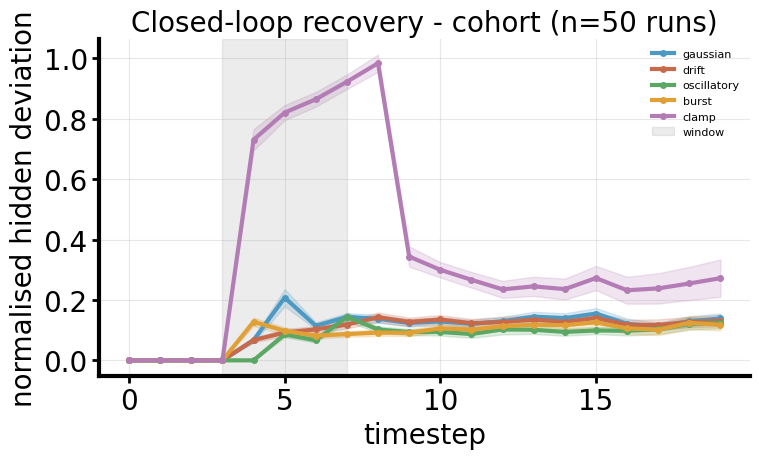

In [171]:
# ---- Cohort CLOSED-LOOP recovery (agent free to move) - the contrast panel ----
# Same per-agent normalisation; no recovery metric, since closed-loop divergence
# is expected to persist for every mode (Part 7).
cl_run_traj = {m: [] for m in COH_MODES}

for rid in COH_RUN_IDS:
    with open(RESULTS_DIR / f"test{rid}" / "128.pickle", "rb") as f:
        agnt = pickle.load(f)
    per_mode = {m: [] for m in COH_MODES}
    for mi in COH_MAZES:
        base = hidden_trajectory(agnt, mi, "gaussian", 0.0, gseed=mi)
        for m in COH_MODES:
            traj = hidden_trajectory(agnt, mi, m, REC_SIGMA, gseed=mi)
            L = min(len(base), len(traj))
            per_mode[m].append(_pad(np.linalg.norm(traj[:L] - base[:L], axis=1), COH_NSTEPS))
    run_means = {m: np.nanmean(np.stack(per_mode[m]), axis=0) for m in COH_MODES}
    win = slice(COH_ONSET, COH_ONSET + COH_DURATION)
    scale = max(np.nanmax(run_means[m][win]) for m in COH_MODES)
    for m in COH_MODES:
        cl_run_traj[m].append(run_means[m] / scale)

fig, ax = plt.subplots(figsize=(8, 5))
t = np.arange(COH_NSTEPS)
for m in COH_MODES:
    D = np.stack(cl_run_traj[m])
    cnt = np.sum(~np.isnan(D), axis=0)
    mean = np.nanmean(D, axis=0); sem = np.nanstd(D, axis=0) / np.sqrt(np.maximum(cnt, 1))
    v = cnt > 0
    ax.plot(t[v], mean[v], marker="o", ms=4, color=OL_COL[m], label=m)
    ax.fill_between(t[v], (mean - sem)[v], (mean + sem)[v], color=OL_COL[m], alpha=0.2)
ax.axvspan(COH_ONSET, COH_ONSET + COH_DURATION - 1, color="grey", alpha=0.15, label="window")
ax.set_xlabel("timestep"); ax.set_ylabel("normalised hidden deviation")
ax.set_title(f"Closed-loop recovery - cohort (n={len(cl_run_traj['gaussian'])} runs)")
ax.grid(True, alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()
